<a href="https://colab.research.google.com/github/EvM82/Object-Detection-with-YOLO-and-Faster-R-CNN/blob/main/CNN_DLDMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Θα χρησιμοπιηθεί το Pascal VOC dataset για πρόβλημα object detection. Υλοποιούνται 3 διαφορετικές προσεγγίσεις, με YOLO, με pretrained Faster RCNN στο οποίο θα προστεθεί ενα επιπλέον convolutional stem πριν το backbone και Faster RCNN με δοκιμή απλοποιημένο custom backbone.

Στόχος είναι να φανεί πώς αλλαγές σε διάφορα κομμάτια τςη αρχικής αρχιτεκτονικής στα Faster RCNN και η χρήση τεχνικών βελτίωσης όπως Batch Normalization, L2 regularization και ρύθμιση των anchors και thresholds επηρρεάζουν την απόδοση.

Επίσης, για κάθε προσέγγιση θα γίνει εκπαίδευση στο clean Pascal VOC dataset και στα δεδομένα με προσθήκη noise και blur.


# Imports and functions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import json
import time
import os

import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

import torchvision.transforms.functional as TF
from torchvision.datasets import VOCDetection
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import MultiScaleRoIAlign

from PIL import ImageFilter
import matplotlib.pyplot as plt
import pandas as pd


import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image, ImageFilter


##Augmentation functions - Common for all experiments

Χρησιμοποιουνται 2 συναρτησεις επεξεργασίας εικόνας οι `add_gaussian_blur` και `add_gaussian_noise`.

Στο Gaussian noise γίνεται προσθήκη τυχαίου θορύβου σε κάθε pixel της εικόνας. Χρησιμοποιείται η `randn_like()` για να δημιουργήσει tensor ίδιου σχήματος με την εκάστοτε εικόνα εισόδου, η οποία όμως θα χει τιμές τυχαίες που ακολουθούν την  κανονική κατανομή. Το tensor (δηλαδή ο θόρβος) προστίθεται στην εικόνα (` image_tensor = image_tensor + noise` ).

Στο Gaussian blur η εικόνα θολώνει με χρήση του μέσου όρου των γειτονικων pixels με αποτέλεσμα να γίνεται smooth στις λεπτομέρειές της. Στον κώδικα αυτό γίνεται στη συνάρτηση `add_gaussian_blur` όπου το radius στα arguments καθορίζει την ένταση του blur και όσο μεγαλώνει τόσο αυξάνετι το blur. Επειδή το φίλτρο `ImageFilter.GaussianBlur()` της βιβλιοθήκης PIL λειτουργεί σε PIL image και όχι σε tensor, γίνεται μετατροπή σε PIL image και μετά αφού εφαρμοστεί το φίλτρο, γίνεται ξανά μετατροπή σε tensor.

Μπορούν να γίνουν 3 χρήσεις των συναρτήσεων: μεμονωμένα ή συνδυαστικά ή καθόλου. Αναλόγως του condition που θα δοθεί στη συνάρτηση `apply_condition()`, θα εφαρμοστεί μία από τις τρεις λειτουργίες:

`voc`--> δεν εφαρμόζεται κάποια αλλοίωση

`noise`--> εφαρμόζεται μόνο Gaussian noise

`noise_blur`--> εφαρμόζεται πρώτα Gaussian noise και στη συνέχεια Gaussian blur.


In [ ]:
def add_gaussian_noise(image_tensor, std=0.05):
    noise = torch.randn_like(image_tensor) * std
    image_tensor = image_tensor + noise
    image_tensor = torch.clamp(image_tensor, 0.0, 1.0)
    return image_tensor


def add_gaussian_blur(image_tensor, radius=1.0):
    image_pil = TF.to_pil_image(image_tensor)
    image_pil = image_pil.filter(ImageFilter.GaussianBlur(radius=radius))
    image_tensor = TF.to_tensor(image_pil)
    return image_tensor


def apply_condition(image_pil, condition="voc", noise_std=0.05, blur_radius=1.0):
    image = TF.to_tensor(image_pil)

    if condition == "voc":
        return image

    if condition == "noise":
        return add_gaussian_noise(image, std=noise_std)

    if condition == "noise_blur":
        image = add_gaussian_noise(image, std=noise_std)
        image = add_gaussian_blur(image, radius=blur_radius)
        return image

## Dataset - Common for the Fatser RCNN

Ο παρακάτω κώδικας δημιουργεί ένα custom dataset για object detection, βασισμένο στο Pascal VOC. Στην αρχή ορίζεται η λίστα VOC_CLASSES, με τις 20 κατηγορίες αντικειμένων του Pascal VOC, όπως car, dog, person, train κτλ, ενώ τα labels των αντικειμένων δίνονται ως αριθμοί από το 1 έως το 20.

Η κλάση `VOCDetectionDataset_augm` κληρονομεί από την ήδη υπάρχουσα κλάση Dataset και κατεβάζει το VOC dataset, αποθηκεύει την παράμετρο condition βάση της οποίας θα καθοριστεί αν η εικόνα θα μείνει κανονική ή αν θα εφαρμοστεί noise, blur ή συνδυασμός τους και ποια η έντασή τους (`noise_std`, `blur_radius`).

Επίοσης, στη PyTorch για object detection, κάθε object της κάθε εικόνας χρειάζεται:

`boxes` --> το bounding box [xmin, ymin, xmax, ymax]

`labels` --> ποια κλάση είναι

`iscrowd` --> αν είναι difficult object


Οπότε στη `_parse_annotation` δημιουργείται ένα dictionary target που περιέχει τα boxes, labels, area και iscrowd. Μετατρέπει δηλαδή τα  annotations του Pascal VOC, τα οποία προέρχονται από XML αρχεία, στη μορφή που απαιτούν τα PyTorch detection models.




*   Για κάθε αντικείμενο της εικόνας από το annotation XML του Pascal VOC, διαβάζεται το όνομα της κλάσης (class_name) και το αντίστοιχο bounding box.

*   Επειδή στις συντεταγμένες του Pascal VOC χρησιμοποιούν 1-based indexing και το PyTorch χρησιμοποιεί 0-based indexing, οπότε, αφαιρείται 1 από τις τιμές xmin, ymin, xmax, ymax.

*   Εφαρμόζεται clamp στις συντεταγμένες, ώστε κάθε bounding box να παραμένει μέσα στα όρια της εικόνας και να αποφεύγονται πιθανά annotation errors. Αν παρόλα αυτά, κάποιο bounding box είναι άκυρο, (xmax <= xmin ή ymax <= ymin), τότε το αντικείμενο αυτό αγνοείται και δεν χρησιμοποιείται στην εκπαίδευση.

*   Τα ονόματα των κλάσεων μετατρέπονται σε αριθμητικά labels με βάση τη θέση τους στη λίστα VOC_CLASSES, προσθέτοντας +1, ώστε το 0 να παραμένει reserved για την background class που θα προστεθεί παρακάτω.

*   Στο Pascal VOC υπάρχει πεδίο difficult το οποίο εδώ γίνεται iscrowd, ώστε να υπάρχει συμβατότητα με το format που απαιτούν τα detection models όπως το Faster R-CNN.


*   Οι λίστες boxes, labels και iscrowd μετατρέπονται σε PyTorch tensors με το κατάλληλο data type.


*   Αν δεν υπάρχει κανένα έγκυρο αντικείμενο στην εικόνα, ο κώδικας δημιουργεί tensors με σωστό κενό σχήμα (empty tensors), ώστε να αποφευχθούν σφάλματα κατά την εκπαίδευση του μοντέλου.




Η μέθοδος `__getitem__` καλείται όποτε μία εικόνα ζητείται. Παίρνει την εικόνα και το annotation από το επίσημο VOC dataset, βρίσκει το πλάτος και το ύψος της εικόνας, μετατρέπει το annotation σε target μέσω της _parse_annotation και στη συνέχεια εφαρμόζει την επιλεγμένη αλλοίωση στην εικόνα με τη συνάρτηση apply_condition. Τέλος, προσθέτει στο target το image_id, ώστε κάθε εικόνα να έχει μοναδικό αναγνωριστικό, και επιστρέφει το ζευγάρι image, target.

Η συνάρτηση `collate_fn` χρησιμοποιείται από τον DataLoader. Επειδή στο object detection κάθε εικόνα μπορεί να έχει διαφορετικό αριθμό αντικειμένων,  δεν μπορεί να γίνει απλό stack όπως γίνεται στο classification. Για αυτό η `collate_fn` οργανώνει το batch σε δύο ομάδες: μία με τις εικόνες και μία με τα αντίστοιχα targets ώστε το batch να έχει συμβατή μορφή με τα μοντέλα object detection της torchvision.

In [ ]:
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]


class VOCDetectionDataset_augm(Dataset):
    def __init__(self, root="./data", year="2007", image_set="train", download=True, condition="voc", noise_std=0.05, blur_radius=1.0,):
        self.dataset = VOCDetection(root=root, year=year, image_set=image_set, download=download,) #loads the oficial dataset
        self.condition = condition
        self.noise_std = noise_std
        self.blur_radius = blur_radius

    def __len__(self):
        return len(self.dataset)

    # VOC XML annotation το μετατρέπει σε μορφή που χρειάζεται το PyTorch detection model.
    def _parse_annotation(self, annotation, width, height):
        objects = annotation["annotation"].get("object", [])

        if isinstance(objects, dict):
            objects = [objects]

        boxes = []
        labels = []
        iscrowd = []

        for obj in objects:
            class_name = obj["name"].strip()
            if class_name not in VOC_CLASSES:
                continue

            bbox = obj["bndbox"]

            xmin = float(bbox["xmin"]) - 1.0
            ymin = float(bbox["ymin"]) - 1.0
            xmax = float(bbox["xmax"]) - 1.0
            ymax = float(bbox["ymax"]) - 1.0

            #Clamp στα όρια - αναγκάζει το box να μείνει μέσα στην εικόνα.
            xmin = max(0.0, min(xmin, width - 1))
            ymin = max(0.0, min(ymin, height - 1))
            xmax = max(0.0, min(xmax, width - 1))
            ymax = max(0.0, min(ymax, height - 1))

            if xmax <= xmin or ymax <= ymin: #skip invalid boxes
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(VOC_CLASSES.index(class_name) + 1)

            difficult = int(obj.get("difficult", 0))
            iscrowd.append(difficult)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        #κενό σε σωστή μορφή
        if boxes.numel() == 0:
            boxes = boxes.reshape((0, 4))
            labels = labels.reshape((0,))
            iscrowd = iscrowd.reshape((0,))
        # εμβαδόν όλων εικόνων
        area = (
            (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
            if len(boxes) > 0
            else torch.zeros((0,), dtype=torch.float32)
        )

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": area,
            "iscrowd": iscrowd,
        }

        return target

    def __getitem__(self, idx):
        image_pil, annotation = self.dataset[idx]
        width, height = image_pil.size

        target = self._parse_annotation(annotation, width, height)

        image = apply_condition(
            image_pil,
            condition=self.condition,
            noise_std=self.noise_std,
            blur_radius=self.blur_radius,
        )

        target["image_id"] = torch.tensor([idx], dtype=torch.int64)

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

## Build dataset -- Common Faster RCNNs

Η συνάρτηση `build_model_and_optimizer()` χρησιμοποιείται για τη δημιουργία του μοντέλου και του optimizer.
Αρχικά καλεiται η `create_model()`, η οποία κατασκευάζει το πλήρες μοντέλο Faster R-CNN.

Οι παράμετροι `num_classes` και `use_bn` καθορίζουν αντίστοιχα τον αριθμό των κλάσεων που θα προβλέπει το μοντέλο και το αν θα χρησιμοποιείται Batch Normalization στα CBL blocks του backbone.
Επίσης, αν η μεταβλητή `use_l2` είναι True, τότε εφαρμόζεται L2 regularization με τιμή 5e-4, διαφορετικά δεν εφαρμόζεται regularization.
Έπειτα δημιουργείται ο optimizer SGD (Stochastic Gradient Descent), ο οποίος χρησιμοποιείται για την ενημέρωση των βαρών του δικτύου κατά τη διαδικασία της εκπαίδευσης.


Η συνάρτηση `build_datasets()` χρησιμοποιείται για τη δημιουργία training set και test set.

Αρχικά δημιουργείται το train_dataset, χρησιμοποιώντας την κλάση `VOCDetectionDataset_augm`, η οποία βασίζεται στο dataset PASCAL VOC και περιλαμβάνει δυνατότητα επεξεργασίας στις εικόνες. Οι παράμετροι root και year καθορίζουν τη θέση αποθήκευσης του dataset και το έτος της έκδοσης που θα χρησιμοποιηθεί.

Η παράμετρος `condition` καθορίζει το είδος της επεξεργασίας που θα εφαρμοστεί στις εικόνες του training set, το οποίο μπορεί να είναι είτε το αρχικό dataset ("voc"), η προσθήκη θορύβου ("noise"), ή προσθήκη θορύβου η θόλωση ("noise_blur"), για τις οποίες χρησιμοποιούνται οι αντίστοιχες συναρτήσεις Augmentation. Για το test δίνεται πάντα condiiton='voc'.

Στη συνέχεια δημιουργείται το test_dataset, με `image_set="test"`. Εδώ η παράμετρος condition ορίζεται σταθερά ως "voc", γιατί θεωρήθηκε καλύτερο για αξιολόγηση να χρησιμοποιούνται οι αρχικές, μη αλλοιωμένες εικόνες του dataset, ανεξάρτητα από το είδος αλλοίωσης που εφαρμόζεται κατά την εκπαίδευση.


In [ ]:
DRIVE_ROOT = Path("/content/drive/MyDrive/fasterrcnn_voc_experiments")
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)

LOCAL_DATA_ROOT = "./data"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Saving experiments to:", DRIVE_ROOT)

Using device: cuda
Saving experiments to: /content/drive/MyDrive/fasterrcnn_voc_experiments


In [ ]:
def build_datasets(condition="voc", root=LOCAL_DATA_ROOT, year="2007", noise_std=0.05, blur_radius=1.0):
    train_dataset = VOCDetectionDataset_augm(
        root=root,
        year=year,
        image_set="train",
        download=True,
        condition=condition,
        noise_std=noise_std,
        blur_radius=blur_radius,
    )

    test_dataset = VOCDetectionDataset_augm(
        root=root,
        year=year,
        image_set="test",
        download=True,
        condition="voc",
        noise_std=noise_std,
        blur_radius=blur_radius,
    )

    return train_dataset, test_dataset


def build_model_and_optimizer(num_classes=21, use_bn=True, use_l2=True, lr=0.005):
    model = create_model(num_classes=num_classes, use_bn=use_bn)

    weight_decay = 5e-4 if use_l2 else 0.0

    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay
    )

    return model, optimizer

## Train one epoch--COMMON FasterRCNNs

Η συνάρτηση `train_one_epoch()` υλοποιεί την εκπαίδευση του μοντέλου (`model.train()` mode ) για μία εποχή. Η συνάρτηση αυτή χρησιμοποιείται στα custom backbone.


Για κάθε batch του dataloader, οι εικόνες και τα αντίστοιχα targets περνάν στο μοντέλο, το οποίο στην περίπτωση του Faster R-CNN επιστρέφει ένα λεξικό από επιμέρους losses.

Μετρώνται οι `loss_classifier` για την ταξινόμηση των τελικών προτάσεων αντικειμένων, η `loss_box_reg` για τη βελτίωση των τελικών bounding boxes, η `loss_objectness` για την εκτίμηση αν ένα προτεινόμενο region περιέχει αντικείμενο στο στάδιο του RPN, και η `loss_rpn_box_reg` για τη βελτίωση των bounding boxes που προτείνονται από το RPN.

Από το άθροισμα όλων των παραπάνω losses προκύπτει η συνολική απώλεια (total_loss) που θα χρησιμοποιηθεί για το backpropagation.


In [ ]:
def train_one_epoch(model, dataloader, optimizer, device, epoch, print_freq=20):
    model.train()

    running_total = 0.0
    running_classifier = 0.0
    running_box_reg = 0.0
    running_objectness = 0.0
    running_rpn_box_reg = 0.0

    for step, (images, targets) in enumerate(dataloader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        loss_classifier = loss_dict["loss_classifier"]
        loss_box_reg = loss_dict["loss_box_reg"]
        loss_objectness = loss_dict["loss_objectness"]
        loss_rpn_box_reg = loss_dict["loss_rpn_box_reg"]

        total_loss = (loss_classifier +loss_box_reg +loss_objectness +loss_rpn_box_reg)

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_total += total_loss.item()
        running_classifier += loss_classifier.item()
        running_box_reg += loss_box_reg.item()
        running_objectness += loss_objectness.item()
        running_rpn_box_reg += loss_rpn_box_reg.item()

        if step % print_freq == 0:
            print(
                f"Epoch {epoch} | Step {step}/{len(dataloader)} | "
                f"Total: {total_loss.item():.4f} | "
                f"Cls: {loss_classifier.item():.4f} | "
                f"Box: {loss_box_reg.item():.4f} | "
                f"Obj: {loss_objectness.item():.4f} | "
                f"RPN Box: {loss_rpn_box_reg.item():.4f}"
            )

    num_batches = len(dataloader)

    epoch_stats = {
        "train_total_loss": running_total / num_batches,
        "train_loss_classifier": running_classifier / num_batches,
        "train_loss_box_reg": running_box_reg / num_batches,
        "train_loss_objectness": running_objectness / num_batches,
        "train_loss_rpn_box_reg": running_rpn_box_reg / num_batches,
    }

    return epoch_stats

Ίδια λογική με την `train_one_epoch`, με βασική διαφορά στα arguments που δέχεται και στο ότι δεν περιλαμβάνει εκτυπώσεις κατά τη διάρκεια της εκπαίδευσης, αλλά επιστρέφει μόνο τα συγκεντρωτικά losses ανά εποχή. Αυτή χρησιμοποιείται στα pre-trained.

In [ ]:
def train_one_epoch_2(model, dataloader, optimizer, device):
    model.train()

    running = {
        "total_loss": 0.0,
        "loss_classifier": 0.0,
        "loss_box_reg": 0.0,
        "loss_objectness": 0.0,
        "loss_rpn_box_reg": 0.0,
    }

    for images, targets in dataloader:
        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        loss_dict = model(images, targets)

        total_loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running["total_loss"] += total_loss.item()
        running["loss_classifier"] += loss_dict["loss_classifier"].item()
        running["loss_box_reg"] += loss_dict["loss_box_reg"].item()
        running["loss_objectness"] += loss_dict["loss_objectness"].item()
        running["loss_rpn_box_reg"] += loss_dict["loss_rpn_box_reg"].item()

    for k in running:
        running[k] /= len(dataloader)

    return running



## Evaluation Function --COMMON for Faster RCNNs

Τα metrics που θα χρησιμοποιηθούν είναι:


*   IoU το οποίο μετρά τον βαθμό επικάλυψης μεταξύ του predicted και του ground truth bounding box.
IoU= Area(Intersection)/Area(Union)


*   Precision μετρά πόσα από τα detections που έκανε το μοντέλο είναι σωστά (TP / (TP + FP))

*   Recall μετρά πόσα από τα πραγματικά objects βρήκε το μοντέλο (TP / (TP + FN))

* F1-score είναι ο μέσος του precision και του recall και εκφράζει την ισορροπία μεταξύ τους.

*   AP (Average Precision) για κάθε κλάση είναι το εμβαδό κάτω από την καμπύλη Precision–Recall για μια κλάση.

*   mAP=mean(AP όλων των classes), δηλαδή ο μέσος όρος των AP σε όλες τις κλάσεις, που συνοψίζει τη συνολική απόδοση του μοντέλου.





Στο παρακάτω κελί υπάρχουν συναρτήσεις αξιολόγησης (evaluation helpers), ώστε να υπολογίζονται και να εμφανίζονται metrics του object detection model στο test set.

Η συνάρτηση `compute_iou()` υπολογίζει το Intersection over Union (IoU) μεταξύ δύο bounding boxes, το οποίο μετρά πόσο καλά επικαλύπτεται το predicted box με το ground truth box και χρησιμοποιείται για να κριθεί αν μια ανίχνευση θεωρείται σωστή.

Η συνάρτηση `_match_predictions_to_targets()` πραγματοποιεί greedy one-to-one matching μεταξύ predicted boxes και ground truth boxes. Ένα detection θεωρείται True Positive (TP) μόνο αν:

*   ανήκει στην ίδια κλάση με το ground truth
*   και το IoU είναι μεγαλύτερο ή ίσο από το προκαθορισμένο threshold


Η συνάρτηση `compute_map()` υπολογίζει το mean Average Precision με VOC-style αξιολόγηση. Συγκεκριμένα, για κάθε κλάση συλλέγονται όλα τα ground truth boxes, συλλέγονται όλες οι προβλέψεις του μοντέλου για τη συγκεκριμένη κλάση και οι προβλέψεις αυτές ταξινομούνται με βάση το confidence score τους.

Στη συνέχεια υπολογίζονται τα True Positives και False Positives για κάθε prediction και δημιουργούνται οι καμπύλες Precision–Recall, από τις οποίες  καμπύλες υπολογίζεται το Average Precision (AP) κάθε κλάσης ως το εμβαδό κάτω από την Precision–Recall curve.
Το τελικό mAP προκύπτει ως ο μέσος όρος των AP όλων των κλάσεων του Pascal VOC dataset.


Το Accuracy που υπολογίζεται εδώ, δεν είναι classification accuracy, αλλά object detection accuracy το οποίο υπολογίζεται ως το ποσοστό σωστών detections σε σχέση με όλες τις αποφάσεις του detector (TP + FP + FN).
Η συνάρτηση print_test_metrics() χρησιμοποιείται για την εκτύπωση των test metrics μετά από κάθε epoch, ώστε να παρακολουθείται η απόδοση του μοντέλου κατά τη διάρκεια της εκπαίδευσης.

Οι συναρτήσεις υπολογισμού των metrics βασίστηκαν στο άρθρο “Evaluating Object Detection Models: Methods and Metrics” του GeeksforGeeks, με τις απαραίτητες αλλαγές στην  υλοποίησή τους ώστε να προσαρμόστούν στη μορφή εξόδου του pretrained Faster R-CNN.

In [ ]:
def compute_iou(box1, box2):
    x1, y1, x2, y2 = [float(v) for v in box1]
    x1g, y1g, x2g, y2g = [float(v) for v in box2]

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter_area = max(0.0, xi2 - xi1) * max(0.0, yi2 - yi1)
    box1_area = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    box2_area = max(0.0, x2g - x1g) * max(0.0, y2g - y1g)
    union_area = box1_area + box2_area - inter_area

    if union_area <= 0:
        return 0.0
    return inter_area / union_area


def _match_predictions_to_targets(pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels, iou_threshold=0.5):
    if len(pred_boxes) == 0:
        return 0, 0, len(gt_boxes), []

    order = sorted(range(len(pred_boxes)), key=lambda i: float(pred_scores[i]), reverse=True)
    matched_gt = set()
    tp = 0
    fp = 0
    matched_ious = []

    for pred_idx in order:
        best_iou = 0.0
        best_gt_idx = -1

        for gt_idx, gt_box in enumerate(gt_boxes):
            if gt_idx in matched_gt:
                continue
            if int(pred_labels[pred_idx]) != int(gt_labels[gt_idx]):
                continue

            iou = compute_iou(pred_boxes[pred_idx], gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_gt_idx >= 0 and best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_gt_idx)
            matched_ious.append(best_iou)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn, matched_ious


def compute_map(detections, annotations, num_classes=20, iou_threshold=0.5):
    """
    mAP@IoU threshold for VOC-style detection.
    detections: list of dicts with boxes, labels, scores
    annotations: list of dicts with boxes, labels
    """
    aps = []

    for cls in range(1, num_classes + 1):
        cls_predictions = []
        n_gt = 0

        gt_by_image = {}
        for img_idx, ann in enumerate(annotations):
            gt_boxes = [box for box, label in zip(ann["boxes"], ann["labels"]) if int(label) == cls]
            gt_by_image[img_idx] = {"boxes": gt_boxes, "matched": [False] * len(gt_boxes)}
            n_gt += len(gt_boxes)

        if n_gt == 0:
            continue

        for img_idx, det in enumerate(detections):
            for box, label, score in zip(det["boxes"], det["labels"], det["scores"]):
                if int(label) == cls:
                    cls_predictions.append({
                        "image_idx": img_idx,
                        "box": box,
                        "score": float(score),
                    })

        cls_predictions.sort(key=lambda x: x["score"], reverse=True)

        tp = []
        fp = []
        for pred in cls_predictions:
            image_gt = gt_by_image[pred["image_idx"]]
            best_iou = 0.0
            best_gt_idx = -1

            for gt_idx, gt_box in enumerate(image_gt["boxes"]):
                iou = compute_iou(pred["box"], gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            if best_gt_idx >= 0 and best_iou >= iou_threshold and not image_gt["matched"][best_gt_idx]:
                tp.append(1.0)
                fp.append(0.0)
                image_gt["matched"][best_gt_idx] = True
            else:
                tp.append(0.0)
                fp.append(1.0)

        if len(tp) == 0:
            aps.append(0.0)
            continue

        tp = torch.tensor(tp).cumsum(0)
        fp = torch.tensor(fp).cumsum(0)
        recalls = tp / max(float(n_gt), 1.0)
        precisions = tp / torch.clamp(tp + fp, min=1e-8)

        # Integral AP.
        mrec = torch.cat([torch.tensor([0.0]), recalls, torch.tensor([1.0])])
        mpre = torch.cat([torch.tensor([0.0]), precisions, torch.tensor([0.0])])
        for i in range(mpre.numel() - 2, -1, -1):
            mpre[i] = torch.maximum(mpre[i], mpre[i + 1])
        idx = torch.where(mrec[1:] != mrec[:-1])[0]
        ap = torch.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]).item()
        aps.append(ap)

    return sum(aps) / len(aps) if len(aps) > 0 else 0.0


@torch.no_grad()
def evaluate_model(model, dataloader, device, iou_threshold=0.5, score_threshold=0.5, max_batches=None):
    model.eval()

    detections = []
    annotations = []
    total_tp = total_fp = total_fn = 0
    all_matched_ious = []

    for batch_idx, (images, targets) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            keep = output["scores"].detach().cpu() >= score_threshold

            pred_boxes = output["boxes"].detach().cpu()[keep].tolist()
            pred_labels = output["labels"].detach().cpu()[keep].tolist()
            pred_scores = output["scores"].detach().cpu()[keep].tolist()

            gt_boxes = target["boxes"].detach().cpu().tolist()
            gt_labels = target["labels"].detach().cpu().tolist()

            tp, fp, fn, matched_ious = _match_predictions_to_targets(
                pred_boxes, pred_labels, pred_scores,
                gt_boxes, gt_labels,
                iou_threshold=iou_threshold,
            )

            total_tp += tp
            total_fp += fp
            total_fn += fn
            all_matched_ious.extend(matched_ious)

            detections.append({"boxes": pred_boxes, "labels": pred_labels, "scores": pred_scores})
            annotations.append({"boxes": gt_boxes, "labels": gt_labels})

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


    accuracy = total_tp / (total_tp + total_fp + total_fn) if (total_tp + total_fp + total_fn) > 0 else 0.0
    mean_iou = sum(all_matched_ious) / len(all_matched_ious) if len(all_matched_ious) > 0 else 0.0
    mAP = compute_map(detections, annotations, num_classes=len(VOC_CLASSES), iou_threshold=iou_threshold)

    return {
        "accuracy": accuracy,
        "mAP": mAP,
        "f1_score": f1_score,
        "precision": precision,
        "recall": recall,
        "mean_iou": mean_iou,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
    }


def print_test_metrics(metrics, epoch=None):
    prefix = f"Test metrics after epoch {epoch}" if epoch is not None else "Test metrics"
    print(f"\n{prefix}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"mAP@0.50: {metrics['mAP']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"Mean IoU: {metrics['mean_iou']:.4f}")
    print(f"TP: {metrics['tp']} | FP: {metrics['fp']} | FN: {metrics['fn']}")


# Faster RCNN with custom backbone

## class Faster RCNN backbone

Παρακάτω υπάρχουν οι κλάσεις για Faster RCNN με custom backbone, βασισμένο εν μέρη στην αρχιτεκτονική του YOLO (χρήση focus layer, cbl blocks για την εξαγωγή χαρακτηριστικών στο backbone).
<br></br>
Αρχικά χρησιμοποιηθηκε Focus layer (`class Focus(nn.Module)`), το οποίο αλλάζει τη μορφη της πληροφορίας (downsampling) χωρίς όμως σημαντική απώλεια πληροφορίας.
Συγκεκριμένα στον κώδικα το spatial resolution (ύψος/πλάτος) πέφτει στο μισό και τα channels γίνονται 4 φορές περισσότερα (χωρίζει την εικόνα σε τέσσερα υποσύνολα pixels βάσει της θέσης τους και τα συνενώνει στο channel dimension (`torch.cat`). Με αυτον τον τρόπο αλλάζει η μορφή (μειώνεται η χωρική πλυπλοκότητα), όχι η διαθέσιμη πληροφορια της εικόνας πριν δωθεί στο backbone.
<br></br>
Η `class CBL(nn.Module)` υλοποιεί επαναχρησιμοποιήσιμο CNN layer και αναλόγως με την τιμή (True/False) της μεταβλητής `use_bn`, θα χρησιμοποιείται και BatchNormalization με σκοπό να εξεταστεί η συμβολή του στα αποτελέσματα.
<br></br>


Η ` class SimpleBackboneMulti(nn.Module)`  δημιουργεί το backbone μοντελο, το οποιο θα παράξει τα features maps ώστε να χρησιμοποιηθούν μετά από το Faster R-CNN.
Το backbone έχει αρχικά ένα Focus layer, όπβς ήδη αναφέρθηκε, το οποίο κάνει downsampling χωρίς σημαντική απώλεια χωρικής πληροφορίας, πριν τα δεδομένα περάσουν στο υπόλοιπο δίκτυο. Για RGB εικόνα, τα κανάλια από 3 γίνονται 12, (3 × 4), ενώ το ύψος και το πλάτος μειώνονται στο μισό.
Στη συνέχεια υπάρχουν 4 CBL layers, τα οποία κάνουν εξαγωγή χαρακτηριστικών.
Επιπλέον, υπάρχουν τρία projection layers, τα οποία είναι 1×1 convolutional layers με στόχο να μετατρέψουν τα διαφορετικά channel sizes των feature maps σε κοινό αριθμό channels (256), ώστε να μπορούν να χρησιμοποιηθούν από το Faster R-CNN. Για αυτό και ρησιμοποιείται `kernel_size=1`, επειδή στόχος είναι να αλλάξει κυρίως ο αριθμός των channels χωρίς να αλλάξει το spatial resolution.
Τέλος το OrderedDict αντιστοιχίζει κάθε feature map με ένα συγκεκριμένο όνομα(scale), ώστε το Faster R-CNN να γνωρίζει ποιο feature map χρησιμοποιεί σε κάθε επίπεδο.
Τελικά, το backbone επιστρέφει πολλά feature maps με ίδιο αριθμό channels αλλά διαφορετικά resolutions, τα οποία χρησιμοποιεί το Faster R-CNN για detection αντικειμένων διαφορετικών μεγεθών.

<br></br>
Η `create_model()` φτιάχνει ολόκληρο το Faster R-CNN model χρησιμοποιώντας το custom backbone.
Το `num_classes=21` είναι οι διαθέσιμες κατηγορίες, και για VOC dataset δίνονται 21, γιατί έχει 20 κλάσεις και το Faster RCNN περιλαμβάνει 20 κλάσεις αντικειμένων και μία επιπλέον κλάση για background κατά το στάδιο της ταξινόμησης.

Πρώτα δημιουργείται το backbone, το οποίο επιστρέφει 3 feature maps 256 καναλιών.
Μετά ορίζεται ο `AnchorGenerator`, ο οποίος δημιουργεί τα anchors του RPN (Region Proposal Network). Τα anchors είναι προκαθορισμένα bounding boxes που τοποθετούνται πάνω στα feature maps του backbone, ώστε το RPN να εντοπίζει πιθανές περιοχές όπου μπορεί να υπάρχει κάποιο αντικείμενο και επειδή το backbone επιστρέφει τρία feature maps διαφορετικών resolutions, ορίζονται και τρία διαφορετικά groups από anchor sizes, ένα για κάθε feature map.

<mark>Η λογική είναι ότι τα feature maps υψηλότερης ανάλυσης χρησιμοποιούνται για μικρότερα αντικείμενα και επομένως αντιστοιχίζονται με μικρότερα anchors, ενώ τα feature maps χαμηλότερης ανάλυσης χρησιμοποιούνται για μεγαλύτερα αντικείμενα και αντιστοιχίζονται με μεγαλύτερα anchors.</mark>
Επιπλέον, ορίζονται και διαφορετικά `aspect_ratios`, ώστε για κάθε anchor size να δοκιμάζονται bounding boxes διαφορετικών σχημάτων, βελτιώνοντας την ικανότητα ανίχνευσης διαφορετικών αντικειμένων.
Χρησιμοποιήθηκαν δύο παραλλαγές anchors, μια πιο απλή, με ένα anchor size ανά feature map, και μία πιο σύνθετη, με πολλαπλά anchor sizes ανά feature map (η δεύτερη εκδοχή είναι με σχόλια στον κώδικα αυτή τη στιγμή).
<mark>Στη συνέχεια χρησιμοποιείται το `MultiScaleRoIAlign`, το οποίο παίρνει και τα feature maps του backbone και επίσης λαμβάνει τα region proposals που παράγει το RPN, από τα οποία εξάγει ένα σταθερού μεγέθους feature representation gia κάθε proposal διαστάσεων 7 × 7. Αυτό είναι απαραίτητο ώστε το επόμενο στάδιο του Faster R-CNN (classification και bounding box regression) να δέχεται είσοδο σταθερού μεγέθους.</mark>




Επίσης, επειδή αρχικά τα αποτελέσματα ήταν πολύ χαμηλά προστέθηκαν κάποιες παράμετροι. Στο RPN παράγεονται region proposals, από τα οποία διατηρούνται τα πιο υποσχόμενα βάσει του objectness score (`rpn_pre_nms_top_n_train`, `rpn_pre_nms_top_n_test`). Στη συνέχεια εφαρμόζεται Non-Maximum Suppression (NMS), το οποίο είναι μια τεχνική για την αφαίρεση πολλών επικαλυπτόμενων προβλέψεων για το ίδιο αντικείμενο. Από όλα τα bounding boxes που προβλέπονται, κρατά αυτό με το υψηλότερο confidence score και απορρίπτει τα υπόλοιπα που έχουν μεγάλη επικάλυψη (IoU) με αυτό, εξασφαλίζοντας έτσι ότι κάθε αντικείμενο ανιχνεύεται μόνο μία φορά και θα αφαιρούνται επικαλυπτόμενα boxes με IoU μεγαλύτερο από το κατώφλι `rpn_nms_thresh`. Επίσης διατηρείται ένας περιορισμένος αριθμός προτάσεων (`rpn_post_nms_top_n_train`, `rpn_post_nms_top_n_test`).

Στο επόμενο στάδιο (ROI Heads), τα region proposals ταξινομούνται και γίνεται πρόβλεψη των bounding boxes. Έπειτα εφαρμόζεται φιλτράρισμα βάσει confidence score (`box_score_thresh`), όπου διατηρούνται μόνο οι προβλέψεις με επαρκή εμπιστοσύνη. Στη συνέχεια εφαρμόζεται εκ νέου NMS (`box_nms_thresh`) για την απομάκρυνση επικαλυπτόμενων detections.

Τέλος, η παράμετρος `box_detections_per_img` περιορίζει τον μέγιστο αριθμό τελικών ανιχνεύσεων ανά εικόνα, συμβάλλοντας στη μείωση των false positives σε περιπτώσεις όπου το μοντέλο παράγει μεγάλο αριθμό προβλέψεων.

In [ ]:
class Focus(nn.Module):
    def forward(self, x):
        return torch.cat([
            x[..., ::2, ::2],
            x[..., ::2, 1::2],
            x[..., 1::2, ::2],
            x[..., 1::2, 1::2]
        ], dim=1)


class CBL(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, use_bn=True):
        super().__init__()
        padding = kernel_size // 2
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=not use_bn) ]
        if use_bn:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.1, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class SimpleBackboneMulti(nn.Module):
    def __init__(self, use_bn=True, out_channels=256):
        super().__init__()
        self.focus = Focus()

        self.layer1 = CBL(12, 32, kernel_size=3, stride=1, use_bn=use_bn)
        self.layer2 = CBL(32, 64, kernel_size=3, stride=2, use_bn=use_bn)
        self.layer3 = CBL(64, 128, kernel_size=3, stride=2, use_bn=use_bn)
        self.layer4 = CBL(128, 256, kernel_size=3, stride=2, use_bn=use_bn)

        self.proj2 = nn.Conv2d(64, out_channels, kernel_size=1)
        self.proj3 = nn.Conv2d(128, out_channels, kernel_size=1)
        self.proj4 = nn.Conv2d(256, out_channels, kernel_size=1)

        self.out_channels = out_channels

    def forward(self, x):
        x = self.focus(x)
        x = self.layer1(x)
        c2 = self.layer2(x)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)

        p2 = self.proj2(c2)
        p3 = self.proj3(c3)
        p4 = self.proj4(c4)

        return OrderedDict({
            "0": p2,
            "1": p3,
            "2": p4,
        })


def create_model(num_classes=21, use_bn=True):
    backbone = SimpleBackboneMulti(use_bn=use_bn, out_channels=256)
    # first anchorss used (1st experiment set)
    anchor_generator = AnchorGenerator(
        sizes=((32,), (64,), (128,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 3
    )

    # second anchorss used (2nd experiment set)
    #anchor_generator = AnchorGenerator(
    #sizes=((16, 32, 64), (32, 64, 128), (128, 256, 512)),
    #aspect_ratios=((0.5, 1.0, 2.0),) * 3
    #)

    roi_pooler = MultiScaleRoIAlign(
        featmap_names=["0", "1", "2"],
        output_size=7,
        sampling_ratio=2
    )

    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=600,
        max_size=1000,

        rpn_pre_nms_top_n_train=1000,
        rpn_pre_nms_top_n_test=500,
        rpn_post_nms_top_n_train=1000,
        rpn_post_nms_top_n_test=100,
        rpn_nms_thresh=0.5,

        box_score_thresh=0.05,
        box_nms_thresh=0.4,
        box_detections_per_img=50,
    )

    return model


def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

## run experiment function (to run and save in Drive multiple versions of experiments)

Η συνάρτηση `run_experiment()` οργανώνει τη διαδικασία ενός πειράματος εκπαίδευσης.

Αρχικά δημιουργεί το dataset για training με βάση τη συνθήκη εκπαίδευσης που έχει οριστεί, όπως αρχικές εικόνες ("voc"), θόρυβος ("noise") ή ("noise_blur") και κατασκευάζει το DataLoader που θα δημιουργήσει τα batches δεδομένων που θα δωθούν στο μοντέλο. Ο DataLoader επιτρέπει την τυχαία αναδιάταξη των δεδομένων (shuffling), τη φόρτωσή τους σε παρτίδες και τη βελτιστοποίηση της χρήσης της μνήμης και των υπολογιστικών πόρων, βοηθώντας την εκπαίδευση του μοντέλου.
Για το training χρησιμοποιείται shuffle=True, ώστε τα δεδομένα να ανακατεύονται σε κάθε εποχή και να αποφεύγεται η υπερπροσαρμογή σε συγκεκριμένη σειρά δειγμάτων, ενώ για το testing στην φάση αξιολόγησης παρακάτω χρησιμοποιείται shuffle=False, ώστε η αξιολόγηση να είναι σταθερή και αναπαραγώγιμη.
Επίσης, επειδή στο object detection οι εικόνες και τα annotations έχουν μεταβλητό μέγεθος και δεν μπορούν να στοιβαχτούν σε απλό tensor batch χρησιμοποιείται collate_fn.


Έπειτα, δημιουργείται το μοντέλο Faster R-CNN μαζί με τον optimizer, σύμφωνα με τις επιλογές του πειράματος, όπως η χρήση Batch Normalization, L2 regularization και learning rate.




In [ ]:
def run_experiment(exp_name,train_condition="voc",use_bn=True,use_l2=True,num_epochs=10,batch_size=4,lr=0.005,noise_std=0.05,blur_radius=1.0,num_workers=0,save_root=DRIVE_ROOT,):

    print(f"\n Running experiment: {exp_name}")
    print(f"train_condition={train_condition}, use_bn={use_bn}, use_l2={use_l2}")

    train_dataset, _ = build_datasets(
        condition=train_condition,
        root=LOCAL_DATA_ROOT,
        year="2007",
        noise_std=noise_std,
        blur_radius=blur_radius,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )


    model, optimizer = build_model_and_optimizer(
        num_classes=21,
        use_bn=use_bn,
        use_l2=use_l2,
        lr=lr,
    )

    model.to(device)

    history = {
        "train_total_loss": [],
        "train_loss_classifier": [],
        "train_loss_box_reg": [],
        "train_loss_objectness": [],
        "train_loss_rpn_box_reg": [],
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_stats = train_one_epoch(model=model,dataloader=train_loader, optimizer=optimizer,device=device,epoch=epoch,print_freq=20)

        for key in epoch_stats:
            history[key].append(float(epoch_stats[key]))


        print(f"\nEpoch {epoch} finished")
        print("-" * 50)

    elapsed = time.time() - start_time

    exp_dir = save_root / exp_name
    exp_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = exp_dir / "model_checkpoint.pth"
    torch.save({
        "exp_name": exp_name,
        "train_condition": train_condition,
        "use_bn": use_bn,
        "use_l2": use_l2,
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "lr": lr,
        "noise_std": noise_std,
        "blur_radius": blur_radius,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
    }, checkpoint_path)

    history_path = exp_dir / "train_history.json"
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    epochs = range(1, len(history["train_total_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_total_loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{exp_name} - Training Total Loss")
    plt.grid(True)
    total_plot_path = exp_dir / "train_total_loss.png"
    plt.savefig(total_plot_path, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history["train_loss_classifier"], marker="o", label="Classifier")
    plt.plot(epochs, history["train_loss_box_reg"], marker="o", label="Box Reg")
    plt.plot(epochs, history["train_loss_objectness"], marker="o", label="Objectness")
    plt.plot(epochs, history["train_loss_rpn_box_reg"], marker="o", label="RPN Box Reg")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{exp_name} - Training Loss Components")
    plt.legend()
    plt.grid(True)
    subloss_plot_path = exp_dir / "train_sub_losses.png"
    plt.savefig(subloss_plot_path, bbox_inches="tight")
    plt.show()
    plt.close()



    return model, history

### Batch Normalization και L2 regularization

Το Batch Normalization είναι μια τεχνική που κανονικοποιεί τις ενδιάμεσες ενεργοποιήσεις ενός νευρωνικού δικτύου μέσα σε κάθε mini-batch (φέρνοντάς τες περίπου σε μέση τιμή 0 και διασπορά 1), ώστε να σταθεροποιεί και να επιταχύνει την εκπαίδευση, επιτρέποντας μειώνοντας την ευαισθησία στην αρχικοποίηση.

Η L2 regularization (ή weight decay) είναι μια τεχνική κανονικοποίησης που προσθέτει έναν όρο ποινής στο loss ανάλογο με το τετράγωνο των βαρών του μοντέλου, ενθαρρύνοντας μικρότερες τιμές βαρών και αποτρέποντας το overfitting, δηλαδή το να “απομνημονεύει” το μοντέλο τα δεδομένα εκπαίδευσης αντί να γενικεύει καλά.

## Experiments

Στο παρακάτω τμήμα κώδικα πραγματοποιείται η εκτέλεση πολλαπλών πειραμάτων εκπαίδευσης, με στόχο τη σύγκριση διαφορετικών συνδυασμών συνθηκών εισόδου και τεχνικών regularization.

Αρχικά ορίζεται η συνθήκη εκπαίδευσης πχ "noise_blur", δηλαδή εάν θα εκπαιδευυτεί το μοντέλο σε dataset με προσθήκη nnoise, blur ή  όχι. Παράλληλα μπορούν ωα εξεταστούν διαφορετικοί συνδυασμοί χρήσης Batch Normalization (BN) και L2 regularization, αναλόγως τους συνδυασμούς των τιμών True False στο `bn_l2_combinations`.

Για κάθε συνδυασμό δημιουργείται ένα ξεχωριστό πείραμα με μοναδικό όνομα, το οποίο περιγράφει τις αντίστοιχες ρυθμίσεις και στη συνέχεια καλείται η συνάρτηση `run_experiment()`, η οποία εκτελεί ολόκληρη τη διαδικασία εκπαίδευσης και αξιολόγησης του Faster R-CNN .



In [ ]:
'''conditions = ["voc", "noise", "noise_blur"]
bn_l2_combinations = [
    (False, False),
    (False, True),
    (True, False),
    (True, True),
]'''

conditions = ["voc"]
bn_l2_combinations = [
    (True, True),
]

all_summaries = []

for condition in conditions:
    for use_bn, use_l2 in bn_l2_combinations:
        exp_name = f"{condition}_bn_{'on' if use_bn else 'off'}_l2_{'on' if use_l2 else 'off'}_lr_20"

        model, history = run_experiment(
            exp_name=exp_name,
            train_condition=condition,
            use_bn=use_bn,
            use_l2=use_l2,
            num_epochs=20,
            batch_size=4,
            lr=0.0005, # 0.001
            noise_std=0.05,
            blur_radius=1.0,
            num_workers=0,
        )




Running experiment: voc_bn_on_l2_on_lr_20
train_condition=voc, use_bn=True, use_l2=True
100%|██████████| 460M/460M [00:12<00:00, 36.0MB/s]
100%|██████████| 451M/451M [00:19<00:00, 23.6MB/s]
Epoch 0 | Step 0/626 | Total: 4.9536 | Cls: 3.0679 | Box: 0.0035 | Obj: 0.6881 | RPN Box: 1.1941
Epoch 0 | Step 20/626 | Total: 2.8868 | Cls: 1.5964 | Box: 0.0070 | Obj: 0.6789 | RPN Box: 0.6045
Epoch 0 | Step 40/626 | Total: 2.3056 | Cls: 0.3326 | Box: 0.0052 | Obj: 0.6563 | RPN Box: 1.3115
Epoch 0 | Step 60/626 | Total: 1.5707 | Cls: 0.1639 | Box: 0.0244 | Obj: 0.5694 | RPN Box: 0.8131
Epoch 0 | Step 80/626 | Total: 1.9774 | Cls: 0.2653 | Box: 0.0518 | Obj: 0.5617 | RPN Box: 1.0986
Epoch 0 | Step 100/626 | Total: 1.4238 | Cls: 0.1448 | Box: 0.0444 | Obj: 0.5234 | RPN Box: 0.7111
Epoch 0 | Step 120/626 | Total: 1.3301 | Cls: 0.0723 | Box: 0.0164 | Obj: 0.5526 | RPN Box: 0.6888
Epoch 0 | Step 140/626 | Total: 1.2655 | Cls: 0.0736 | Box: 0.0264 | Obj: 0.4214 | RPN Box: 0.7442
Epoch 0 | Step 160/626

## Testing

Παρακάτω πραγματοποιείται αξιολόγηση των ήδη εκπαιδευμένων μοντέλων στο test set του Pascal VOC. Η μεταβλητή conditions έπαιρνε τις τιμές ανάλογως αν υπήρχε χρήση των augmentation functions ή όχι στο εκάστοτε πείραμα ('voc' , 'noise', noise_blur'). Επίσης μπορύν να φορτωθούν τα μοντέλα αναλογα των διαφορετικών συνδυασμών χρήσης Batch Normalization (BN) και L2 regularization με τις τιμές ενεργοποιησης (True ) και απενεργοποιησης (False) των δύο μεταβλητών use_bn, use_l2 αντίστοιχα.

Για κάθε πείραμα φορτώνεται το αντίστοιχο αποθηκευμένο checkpoint του μοντέλου από το Google Drive, ανακατασκευάζεται το μοντέλο με τις ίδιες παραμέτρους εκπαίδευσης και στη συνέχεια φορτώνονται τα εκπαιδευμένα weights και δημιουργείται το test dataset με την δωθείσα συνθήκη condition.

Τέλος, υπολογίζονται και εμφανίζονται τα βασικά metrics αξιολόγησης του object detection μοντέλου: Accuracy, mAP@0.5, Precision, Recall, F1-score και Mean IoU, για σύγκριση της απόδοσης μεταξύ των διαφορετικών αρχιτεκτονικών και ρυθμίσεων.

In [ ]:
conditions = ["noise_blur"]
bn_l2_combinations = [
    (False, False),
    (True, True),
]

for condition in conditions:
    for use_bn, use_l2 in bn_l2_combinations:
        exp_name = f"{condition}_bn_{'on' if use_bn else 'off'}_l2_{'on' if use_l2 else 'off'}_lr_20"
        checkpoint_path = DRIVE_ROOT / exp_name / "model_checkpoint.pth"

        print(f"\nTESTING {exp_name} ")

        checkpoint = torch.load(checkpoint_path, map_location=device)

        model, optimizer = build_model_and_optimizer(
            num_classes=21,
            use_bn=use_bn,
            use_l2=use_l2,
            lr=0.0005,
        )

        model.load_state_dict(checkpoint["model_state_dict"])
        model.to(device)

        _, test_dataset = build_datasets(
            condition=condition,
            root=LOCAL_DATA_ROOT,
            year="2007",
            noise_std=0.05,
            blur_radius=1.0,
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=4,
            shuffle=False,
            num_workers=0,
            collate_fn=collate_fn,
        )

        test_metrics = evaluate_model(
            model=model,
            dataloader=test_loader,
            device=device,
            iou_threshold=0.5,
            score_threshold=0.05, #0.5, 0.3
        )

        for k, v in test_metrics.items():
            print(f"test_{k}: {v:.4f}")




TESTING noise_blur_bn_off_l2_off_lr_20 
test_accuracy: 0.0173
test_mAP: 0.0002
test_f1_score: 0.0340
test_precision: 0.0280
test_recall: 0.0435
test_mean_iou: 0.6073
test_tp: 651.0000
test_fp: 22611.0000
test_fn: 14325.0000

TESTING noise_blur_bn_on_l2_on_lr_20 
test_accuracy: 0.0282
test_mAP: 0.0010
test_f1_score: 0.0548
test_precision: 0.0483
test_recall: 0.0632
test_mean_iou: 0.6135
test_tp: 947.0000
test_fp: 18661.0000
test_fn: 14029.0000




# Faster RCNN with Pre-Trained backbone and added stem

In [ ]:
SAVE_ROOT = Path("/content/drive/MyDrive/faster_rcnn_stem_vol2")
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

Δημιουργίa των train, test loaders. Ανάλογα το αν θα γίνει  χρήση ή οχι αλλοιωμένου dataset αλλάζει το condition.

In [ ]:
from torch.utils.data import DataLoader

train_dataset, test_dataset = build_datasets(condition="noise_blur") #"voc"

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

100%|██████████| 460M/460M [00:02<00:00, 209MB/s]
100%|██████████| 451M/451M [00:02<00:00, 198MB/s]


## Model pretrained Faster R-CNN

Ένα Faster R-CNN, αποτελείται από



*   backbone features extractor
(ResNet εδώ), ο οποίος εξάγει σημαντικά χαρ/κα, μοτίβα

*   Region Proposal Network (RPN), το οποίο δίνει προτάσεις περιοχών ενδιαφέροντος, στις οποίες πιθανώς υπάρχουν αντικείμενα και τις οποίες αξίζει να ελέγξει το δίκτυο
*   ROI Heads, όπου γίνεται το classification για κάθε region από αυτές, καθώς και καλύτερος προσδιορισμός των bounding box των αντικειμένων.
Συγκεκριμένα το μοτνέλο κατά την εκπαίδευση, μαθαίνει να παράγει feature maps από  τα οποία θα βγουν προτεινόμενες περιοχές ενδιαφέροντος και στη συνέχεια και στη συνέχεια οι ROI heads θα βγάλουν έξοδο το class label και bounding box για τα objects.

Στόχος είναι στην εικόνα εισόδου να εντοπίζει ποια αντικείμενα υπάρχουν και σε ποια θέση βρίσκονται στην εικόνα.



<br> </br>
Παρακάτω, χρησιμοποιείται ένα τέτοιο pretrained μοντέλο Faster R-CNN και επιπλέον, στο μοντέλο προστίθεται ένα custom stem module, το οποίο μπαίνει πριν από το όλο δίκτυο που περιγράφτηκε πιο πάνω. Σκοπός είναι να προσπαθήσει να μαθει το stem να τονίζει/ενισχύει κάποια χρήσιμα χαρακτηριστικά της εικόνας πριν αυτή δωθεί ως input στο δίκτυο, να λειτουργησει δηλαδή ως feature adapter, μετασχηματίζοντας την είσοδο πριν αυτή εισαχθεί στο pretrained δίκτυο.

<br> </br>

Αρχικά εκπαιδεύεται μόνο το πρόσθετο stem, ενώ το υπόλοιπο Faster R-CNN παραμένει παγωμένο (frozen), καθώς είναι ήδη pretrained και επιθυμούμε να διατηρηθούν τα χαρακτηριστικά που έχει μάθει. Με αυτόν τον τρόπο, το stem μαθαίνει έναν αρχικό μετασχηματισμό της εικόνας ώστε η έξοδός του να είναι πιο συμβατή με την είσοδο που αναμένει το pretrained backbone, χωρίς να αλλοιώνονται τα pretrained weights του αρχικού μοντέλου.

Στη συνέχεια πραγματοποιείται fine-tuning ολόκληρου του μοντέλου, ώστε τόσο το stem όσο και το pretrained Faster R-CNN να προσαρμοστούν στο Pascal VOC dataset.Γίνεται δηλαδή transfer learning στο νέο dataset με την προσθήκη του extra convolutional stem.

'Οπως ήδη αναφέρθηκε στο Faster RCNN είναι μια έξτρα κλάση το background οπότε το επειδή το voc έχει κανονικά 20, θα δωθούν 21.

In [ ]:
NUM_CLASSES = 21

### baseline

Εδώ φορτώνεται το pretrained μοντέλο Faster R-CNN με backbone το ResNet-50 και Feature Pyramid Network (FPN), το οποίο έχει ήδη εκπαιδευτεί σε μεγάλο dataset γενικής ανίχνευσης αντικειμένων.
<br></br>
Το backbone χρησιμοποιείται για την εξαγωγή χαρακτηριστικών από την εικόνα, ενώ το υπόλοιπο δίκτυο αναλαμβάνει την πρόταση περιοχών ενδιαφέροντος και την τελική ανίχνευση αντικειμένων.
<br></br>
Η βασική τροποποίηση που πραγματοποιείται είναι στο τελευταίο classification head του detector, δηλαδή στο box predictor των ROI Heads. Συγκεκριμένα, αντικαθίσταται ο αρχικός ταξινομητής με νέο FastRCNNPredictor, ώστε η έξοδος να αντιστοιχεί στις 21 κλάσεις του Pascal VOC dataset (20 κατηγορίες αντικειμένων + 1 background class).

In [ ]:
def get_fasterrcnn_baseline(num_classes=21):
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(in_features,num_classes)

    return model

## custom stem

Πριν από το detection pipeline προστίθεται ένα custom stem module, το οποίο λειτουργεί ως learnable προ-επεξεργαστής της εικόνας. Στόχος του είναι όπως αναφέρθηκε και πιο πάνω, να μετασχηματίσει την input εικόνα ώστε να βοηθά το pretrained Faster R-CNN να εξάγει feature maps.

Στη συγκεκριμένη περίπτωση, το stem χρησιμοποιείται ώστε να μελετηθεί πώς η προσθήκη ενός επιπλέον αρχικού module, επηρεάζει την απόδοση του μοντέλου, χωρίς να τροποποιηθεί άμεσα η εσωτερική αρχιτεκτονική του pretrained μοντέλου.

Αρχικά εκπαιδεύεται μόνο το stem, ενώ τα υπόλοιπα μέρη του detector παραμένουν παγωμένα. Έτσι, διατηρείται η pretrained γνώση του Faster R-CNN. Στη συνέχεια γίνεται fine-tuning ολόκληρου του μοντέλου για λίγες εποχές ( λόγω διαθέσιμων υπολογιστικών πόρων), ώστε το stem και ο detector να προσαρμοστούν καλύτερα μεταξύ τους, χωρίς εκπαίδευση από την αρχή.
<br></br>
Το stem αποτελείται από ένα convolutional layer 3×3 που αυξάνει τα κανάλια από 3 σε 16, ακολουθούμενο από Batch Normalization και ReLU, και ένα δεύτερο convolutional layer 1×1 που επαναφέρει τα κανάλια από 16 σε 3, ώστε να είναι συμβατά με την είσοδο του pretrained Faster R-CNN.

In [ ]:
class SmallStem(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 3, kernel_size=1)
        )

    def forward(self, x):
        return self.stem(x)

Επειδή το torchvision Faster R-CNN (το pretrained model που χρησιμοποιείται)δέχεται ως είσοδο λίστα εικόνων, όπου κάθε εικόνα έχει μορφή [C, H, W], αλλά το stem είναι Conv2d και δέχεται είσοδο batch [B, C, H, W], για αυτό χρησιμοποιείται η κλάση `FasterRCNNWithStem`, ώστε να εφαρμοστεί πρώτα το custom stem σε κάθε εικόνα ξεχωριστά και στη συνέχεια οι επεξεργασμένες εικόνες να δοθούν στο αρχικό Faster R-CNN ως λίστα εικόνων.
Κάθε εικόνα δηλαδή, που αρχικά έχει μορφή [C, H, W], μετατρέπεται προσωρινά σε batch με unsqueeze(0) σε [1, C, H, W], περνάει από το stem και μετά επανέρχεται σε μορφή [C, H, W] με squeeze(0)  (`self.stem(img.unsqueeze(0)).squeeze(0)`).

In [ ]:
class FasterRCNNWithStem(nn.Module):
    def __init__(self, detector, stem):
        super().__init__()
        self.stem = stem
        self.detector = detector

    def forward(self, images, targets=None):
        images = [
            self.stem(img.unsqueeze(0)).squeeze(0)
            for img in images
        ]

        if targets is not None:
            return self.detector(images, targets)

        return self.detector(images)

Παρακάτω είανι η συνάρτηση γαι δημιουργία  model with stem.


*   Το `stem = SmallStem()` φτιάχνει το extra convolutional stem που θα μπει πριν από το Faster R-CNN.

*   Το `model = FasterRCNNWithStem(detector=detector, stem=stem)` τυλίγει το pretrained detector μαζί με το stem, ώστε κάθε εικόνα να περνά πρώτα από το stem και μετά από το Faster R-CNN.

*   Το `detector = get_fasterrcnn_baseline(num_classes=21)` φτιάχνει το pretrained Faster R-CNN με ResNet50-FPN και αλλάζει το τελευταίο prediction head ώστε να βγάζει 21 κλάσεις για Pascal VOC.






In [ ]:
def get_fasterrcnn_with_stem(num_classes=21):
    detector = get_fasterrcnn_baseline(num_classes=num_classes)
    stem = SmallStem()

    model = FasterRCNNWithStem(detector=detector, stem=stem)

    return model

Συναρτηση που παγωνει τον detector ωστε να εκπαιδευετι απο το μηδεν μόνο το stem για αρχή.

In [ ]:
def freeze_detector(model):
    for p in model.detector.parameters():
        p.requires_grad = False

    for p in model.stem.parameters():
        p.requires_grad = True

Συναρτηση που ξε-παγωνει τον detector ωστε να εκπαιδευετι μαζί με το εκπαιδευμενο πλέον stem.

In [ ]:
def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

### Δημιουργία μοντέλου με custom και freeze για εκπαιδευση μόνο stem

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_fasterrcnn_with_stem(num_classes=21)
model.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 113MB/s]


FasterRCNNWithStem(
  (stem): SmallStem(
    (stem): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 3, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (detector): FasterRCNN(
    (transform): GeneralizedRCNNTransform(
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        Resize(min_size=(800,), max_size=1333, mode='bilinear')
    )
    (backbone): BackboneWithFPN(
      (body): IntermediateLayerGetter(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): FrozenBatchNorm2d(64, eps=0.0)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), st

## Εκπαίδευση--Θα γίνει εκπάιδευση  μόνο stem, frozen detector και μετά fine-tune όλο το model.

In [ ]:
exp_name = "fasterrcnn_with_stem__noise_blur_final"
exp_dir = SAVE_ROOT / exp_name
exp_dir.mkdir(parents=True, exist_ok=True)
history = {
    "stage": [],
    "epoch": [],
    "train_total_loss": [],
    "train_loss_classifier": [],
    "train_loss_box_reg": [],
    "train_loss_objectness": [],
    "train_loss_rpn_box_reg": [],
}

### Μόνο stem και freeze pre-trained model

In [ ]:
model = get_fasterrcnn_with_stem(num_classes=21).to(device)

freeze_detector(model)

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3,
    momentum=0.9,
    weight_decay=5e-4
)

for epoch in range(5):
    train_metrics = train_one_epoch_2(model, train_loader, optimizer, device)

    history["stage"].append("frozen_stem")
    history["epoch"].append(epoch + 1)
    history["train_total_loss"].append(train_metrics["total_loss"])
    history["train_loss_classifier"].append(train_metrics["loss_classifier"])
    history["train_loss_box_reg"].append(train_metrics["loss_box_reg"])
    history["train_loss_objectness"].append(train_metrics["loss_objectness"])
    history["train_loss_rpn_box_reg"].append(train_metrics["loss_rpn_box_reg"])


    print(f"\nEpoch {epoch+1}")

    for k, v in train_metrics.items():
        print(f"{k}: {v:.4f}")


Epoch 1
total_loss: 3.1353
loss_classifier: 2.7372
loss_box_reg: 0.2670
loss_objectness: 0.1017
loss_rpn_box_reg: 0.0294

Epoch 2
total_loss: 2.9546
loss_classifier: 2.5607
loss_box_reg: 0.2622
loss_objectness: 0.1018
loss_rpn_box_reg: 0.0300

Epoch 3
total_loss: 2.9372
loss_classifier: 2.5412
loss_box_reg: 0.2657
loss_objectness: 0.1002
loss_rpn_box_reg: 0.0301


### Unfreeze pretrained model & train

In [ ]:
unfreeze_all(model)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-4,
    momentum=0.9,
    weight_decay=5e-4
)

for epoch in range(5):
    train_metrics = train_one_epoch_2(model, train_loader, optimizer, device)


    history["stage"].append("unfreeze_stem")
    history["epoch"].append(epoch + 1)
    history["train_total_loss"].append(train_metrics["total_loss"])
    history["train_loss_classifier"].append(train_metrics["loss_classifier"])
    history["train_loss_box_reg"].append(train_metrics["loss_box_reg"])
    history["train_loss_objectness"].append(train_metrics["loss_objectness"])
    history["train_loss_rpn_box_reg"].append(train_metrics["loss_rpn_box_reg"])


    print(f"\nEpoch {epoch+1}")

    for k, v in train_metrics.items():
        print(f"{k}: {v:.4f}")


Epoch 1
total_loss: 0.7125
loss_classifier: 0.3706
loss_box_reg: 0.2665
loss_objectness: 0.0483
loss_rpn_box_reg: 0.0269

Epoch 2
total_loss: 0.6852
loss_classifier: 0.3423
loss_box_reg: 0.2908
loss_objectness: 0.0294
loss_rpn_box_reg: 0.0226

Epoch 3
total_loss: 0.6206
loss_classifier: 0.2977
loss_box_reg: 0.2772
loss_objectness: 0.0243
loss_rpn_box_reg: 0.0213

Epoch 4
total_loss: 0.5517
loss_classifier: 0.2507
loss_box_reg: 0.2599
loss_objectness: 0.0205
loss_rpn_box_reg: 0.0205

Epoch 5
total_loss: 0.4998
loss_classifier: 0.2175
loss_box_reg: 0.2444
loss_objectness: 0.0181
loss_rpn_box_reg: 0.0197


save model + plot

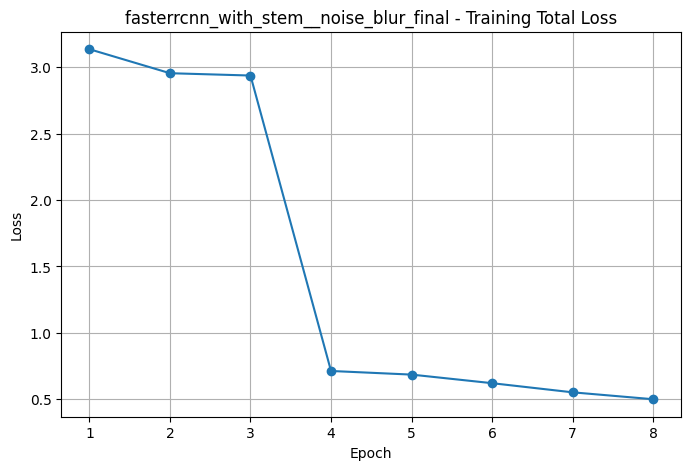

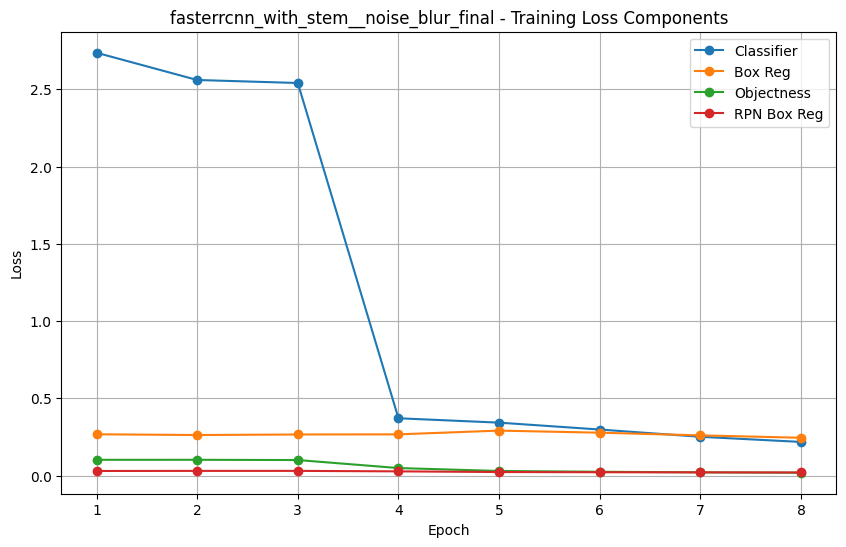

Saved model to: /content/drive/MyDrive/faster_rcnn_stem_vol2/fasterrcnn_with_stem__noise_blur_final/final_model_vol2_stem_noise.pth
Saved history to: /content/drive/MyDrive/faster_rcnn_stem_vol2/fasterrcnn_with_stem__noise_blur_final/train_history.json


In [ ]:
# Save final model
model_path = exp_dir / "final_model_vol2_stem_noise.pth"
torch.save(model.state_dict(), model_path)

# Save training history
history_path = exp_dir / "train_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

# Plot total loss
epochs = range(1, len(history["train_total_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_total_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{exp_name} - Training Total Loss")
plt.grid(True)
plt.savefig(exp_dir / "train_total_loss.png", bbox_inches="tight")
plt.show()
plt.close()

# Plot sub-losses
plt.figure(figsize=(10, 6))
plt.plot(epochs, history["train_loss_classifier"], marker="o", label="Classifier")
plt.plot(epochs, history["train_loss_box_reg"], marker="o", label="Box Reg")
plt.plot(epochs, history["train_loss_objectness"], marker="o", label="Objectness")
plt.plot(epochs, history["train_loss_rpn_box_reg"], marker="o", label="RPN Box Reg")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{exp_name} - Training Loss Components")
plt.legend()
plt.grid(True)
plt.savefig(exp_dir / "train_sub_losses.png", bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved model to: {model_path}")
print(f"Saved history to: {history_path}")

## Εκπαίδευση--Θα γίνει εκπάιδευση στο pretrained μοντέλο, χωρίς προσθήκη stem

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_fasterrcnn_baseline(num_classes=21).to(device)

exp_name = "baseline_fasterrcnn_voc_vol2"
exp_dir = SAVE_ROOT / exp_name
exp_dir.mkdir(parents=True, exist_ok=True)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-4,
    momentum=0.9,
    weight_decay=5e-4
)

history = {
    "epoch": [],
    "train_total_loss": [],
    "train_loss_classifier": [],
    "train_loss_box_reg": [],
    "train_loss_objectness": [],
    "train_loss_rpn_box_reg": [],
}

for epoch in range(7):
    train_metrics = train_one_epoch_2(model, train_loader, optimizer, device)

    history["epoch"].append(epoch + 1)
    history["train_total_loss"].append(train_metrics["total_loss"])
    history["train_loss_classifier"].append(train_metrics["loss_classifier"])
    history["train_loss_box_reg"].append(train_metrics["loss_box_reg"])
    history["train_loss_objectness"].append(train_metrics["loss_objectness"])
    history["train_loss_rpn_box_reg"].append(train_metrics["loss_rpn_box_reg"])

    print(f"\n[Baseline Fine-tuning] Epoch {epoch+1}")
    for k, v in train_metrics.items():
        print(f"{k}: {v:.4f}")


    torch.save(
    {
        "model_state_dict": model.state_dict(),
        "history": history,
        "num_classes": 21,
        "exp_name": exp_name,
    },
    exp_dir / "model_checkpoint.pth"
)


[Baseline Fine-tuning] Epoch 1
total_loss: 0.7531
loss_classifier: 0.3735
loss_box_reg: 0.3430
loss_objectness: 0.0185
loss_rpn_box_reg: 0.0181

[Baseline Fine-tuning] Epoch 2
total_loss: 0.5508
loss_classifier: 0.2207
loss_box_reg: 0.2978
loss_objectness: 0.0142
loss_rpn_box_reg: 0.0181

[Baseline Fine-tuning] Epoch 3
total_loss: 0.4601
loss_classifier: 0.1676
loss_box_reg: 0.2614
loss_objectness: 0.0132
loss_rpn_box_reg: 0.0178

[Baseline Fine-tuning] Epoch 4
total_loss: 0.4099
loss_classifier: 0.1471
loss_box_reg: 0.2341
loss_objectness: 0.0113
loss_rpn_box_reg: 0.0174

[Baseline Fine-tuning] Epoch 5
total_loss: 0.3757
loss_classifier: 0.1354
loss_box_reg: 0.2133
loss_objectness: 0.0100
loss_rpn_box_reg: 0.0170

[Baseline Fine-tuning] Epoch 6
total_loss: 0.3541
loss_classifier: 0.1279
loss_box_reg: 0.2001
loss_objectness: 0.0094
loss_rpn_box_reg: 0.0167

[Baseline Fine-tuning] Epoch 7
total_loss: 0.3362
loss_classifier: 0.1212
loss_box_reg: 0.1899
loss_objectness: 0.0086
loss_rpn_b

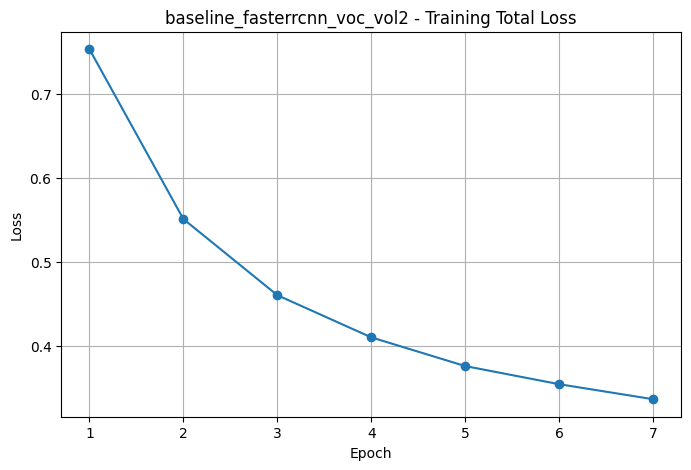

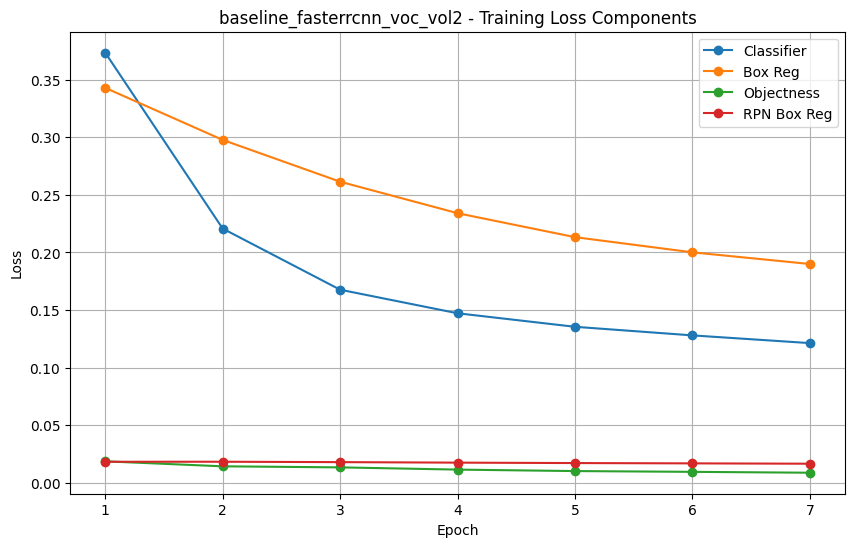

Saved model to: /content/drive/MyDrive/faster_rcnn_stem_vol2/baseline_fasterrcnn_voc_vol2/final_model_noise_pretrained.pth
Saved history to: /content/drive/MyDrive/faster_rcnn_stem_vol2/baseline_fasterrcnn_voc_vol2/train_history.json


In [ ]:
# Save final model
model_path = exp_dir / "final_model_noise_pretrained.pth"
torch.save(model.state_dict(), model_path)

# Save training history
history_path = exp_dir / "train_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

# Plot total loss
epochs = range(1, len(history["train_total_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_total_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{exp_name} - Training Total Loss")
plt.grid(True)
plt.savefig(exp_dir / "train_total_loss.png", bbox_inches="tight")
plt.show()
plt.close()

# Plot sub-losses
plt.figure(figsize=(10, 6))
plt.plot(epochs, history["train_loss_classifier"], marker="o", label="Classifier")
plt.plot(epochs, history["train_loss_box_reg"], marker="o", label="Box Reg")
plt.plot(epochs, history["train_loss_objectness"], marker="o", label="Objectness")
plt.plot(epochs, history["train_loss_rpn_box_reg"], marker="o", label="RPN Box Reg")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{exp_name} - Training Loss Components")
plt.legend()
plt.grid(True)
plt.savefig(exp_dir / "train_sub_losses.png", bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved model to: {model_path}")
print(f"Saved history to: {history_path}")

## Eval run

Για το evaluation είναι κοινός κώδικς για κάθε μοντέλο και κάθε φορά φορτωνονταν το μοντέλο από το drive. Τα αποτελέσματα παρουσιάζονται πιο κάτω στο αντίστοιχο section 'Αποτελέσματα' συγκεντρωμένα.

In [ ]:
# If the pretrained baseline model is used
model = get_fasterrcnn_baseline(num_classes=NUM_CLASSES)

#If the pretrained with the added stem is used
#model = get_fasterrcnn_with_stem(num_classes=NUM_CLASSES)

# weights
model.load_state_dict(torch.load('/content/drive/MyDrive/faster_rcnn_no_stem/baseline_fasterrcnn_voc/final_model.pth'))
#model.load_state_dict(torch.load('exp_dir/final_model_vol2_stem.pth'))

model.eval()
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Στο score threshold δοκιμάστηκαν οι τιμές 0.05, 0.3, 0.5.

In [ ]:
test_metrics = evaluate_model(
    model=model,
    dataloader=test_loader,
    device=device,
    iou_threshold=0.5,
    score_threshold=0.05 #0.5, 0.3, 0.05
)

print_test_metrics(test_metrics)


Test metrics
Accuracy: 0.1692
mAP@0.50: 0.7664
F1 Score: 0.2894
Precision: 0.1713
Recall: 0.9324
Mean IoU: 0.7843
TP: 13963 | FP: 67571 | FN: 1013


# YOLOv5

Το YOLOv5 (You Only Look Once v5) χρησιμοποιείται γαι object detection και ανήκει στις μεθόδους single-stage detectors γιατί πραγματοποιεί ταυτόχρονα εντοπισμό και ταξινόμηση αντικειμένων σε μία μόνο διέλευση από το δίκτυο, αυξάνοντας την ταχύτητα εκπαίδευσης ενώ μπορεί να ανιχνεύει αντικείμενα με καλή ακρίβεια.


Η αρχιτεκτονική του μοιάζει με αυτή του Faster RCNN, καθώς αποτελείται από τρία βασικά μέρη: το backbone, το οποίο εξάγει χαρακτηριστικά από την εικόνα εισόδου, το neck, που συνδυάζει πληροφορία από διαφορετικά επίπεδα (feature fusion), και το head, το οποίο παράγει τις τελικές προβλέψεις (bounding boxes, κατηγορίες και confidence scores). Επίσης, χρησιμοποιεί τεχνικές όπως convolutional layers, residual συνδέσεις και multi-scale prediction.

Η διαφοροποίησή του από το Faster R-CNN, όπως αναφέρθηκε, είναι ότι το YOLO είναι single-stage detector και δεν διαχωρίζει τη διαδικασία σε στάδιο παραγωγής region proposals και σε στάδιο ταξινόμησης, αλλά, πραγματοποιεί απευθείας την πρόβλεψη των bounding boxes και των κατηγοριών σε μία μόνο διέλευση από το δίκτυο.

## Clone YOLOv5 και install requirements

In [ ]:
%cd /content
!git clone https://github.com/ultralytics/yolov5
%cd /content/yolov5
!pip install -r requirements.txt

/content
Cloning into 'yolov5'...
remote: Enumerating objects: 17968, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 17968 (delta 72), reused 24 (delta 22), pack-reused 17870 (from 3)
Receiving objects: 100% (17968/17968), 17.13 MiB | 20.37 MiB/s, done.
Resolving deltas: 100% (12229/12229), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 13.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [ ]:
%cd /content
!mkdir -p /content/datasets/VOC/images
%cd /content/datasets/VOC/images

!wget -nc https://github.com/ultralytics/assets/releases/download/v0.0.0/VOCtrainval_06-Nov-2007.zip
!wget -nc https://github.com/ultralytics/assets/releases/download/v0.0.0/VOCtest_06-Nov-2007.zip
!wget -nc https://github.com/ultralytics/assets/releases/download/v0.0.0/VOCtrainval_11-May-2012.zip

!unzip -q -o VOCtrainval_06-Nov-2007.zip
!unzip -q -o VOCtest_06-Nov-2007.zip
!unzip -q -o VOCtrainval_11-May-2012.zip

/content
/content/datasets/VOC/images
--2026-05-11 12:30:52--  https://github.com/ultralytics/assets/releases/download/v0.0.0/VOCtrainval_06-Nov-2007.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/436a9e58-3d8b-4acc-a645-387416dff20d?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-11T13%3A28%3A39Z&rscd=attachment%3B+filename%3DVOCtrainval_06-Nov-2007.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-11T12%3A27%3A56Z&ske=2026-05-11T13%3A28%3A39Z&sks=b&skv=2018-11-09&sig=wsJ9VLtQLU%2Bi5BTizB8LAoDIfdjKgfJpkd3USnjD3Ac%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3ODUwNjI1MiwibmJ

In [ ]:
# check address
!ls /content/datasets/VOC/images
!ls /content/datasets/VOC/images/VOCdevkit
!ls /content/datasets/VOC/images/VOCdevkit/VOC2007 | head
!ls /content/datasets/VOC/images/VOCdevkit/VOC2012 | head

VOCdevkit		 VOCtrainval_06-Nov-2007.zip
VOCtest_06-Nov-2007.zip  VOCtrainval_11-May-2012.zip
VOC2007  VOC2012
Annotations
ImageSets
JPEGImages
SegmentationClass
SegmentationObject
Annotations
ImageSets
JPEGImages
SegmentationClass
SegmentationObject


Το VOC_CLASSES περιέχει τις κατηγορίες που υπάρχουν στο dataset.

In [ ]:
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

## XML → YOLO

Στο YOLO  ως είσοδο δίνονται εικόνες μαζί με τα αντίστοιχα label files που περιέχουν τα bounding boxes, καθώς και ένα YAML αρχείο που περιγράφει τη δομή του dataset και τις κλάσεις και το YOLO αναλαμβάνει εσωτερικά το loading, resize, batching και preprocessing των δεδομένων.

Για να δουλέψει το YOLO, κάθε εικόνα πρέπει να έχει αντίστοιχο .txt label file σε μορφή: class_id, x_center, y_center και width height,
όπου οι συντεταγμένες είναι normalized στο [0,1].

Στο Pascal VOC, τα annotations δίνονται σε μορφή XML, επομένως απαιτείται μετατροπή των annotations από VOC XML σε YOLO TXT format. Η μετατροπή αυτή περιλαμβάνει την εξαγωγή των bounding boxes και τη μετατροπή τους σε κανονικοποιημένες συντεταγμένες κέντρου και διαστάσεων.

Συγκεκριμένα η συνάρτηση `convert_label`, η οποία διαβάζει κάθε XML αρχείο, εντοπίζει τις διαστάσεις της εικόνας (width, height) και εξάγει για κάθε αντικείμενο την κλάση και τις συντεταγμένες του bounding box (xmin, xmax, ymin, ymax).

Η `convert_label` χρησιμοποιεί την συνάρτηση `convert_box` η οποία μετατρέπει τις VOC συντεταγμένες σε μορφή YOLO υπολογίζοντας το κέντρο του bounding box ως:

$$
x_{center} = \frac{x_{min} + x_{max}}{2 \cdot width}
$$

$$
y_{center} = \frac{y_{min} + y_{max}}{2 \cdot height}
$$

$$
box_{width} = \frac{x_{max} - x_{min}}{width}
$$

$$
box_{height} = \frac{y_{max} - y_{min}}{height}
$$

Έτσι, κάθε αντικείμενο αποθηκεύεται στο αντίστοιχο .txt αρχείο με τη μορφή:
class_id, x_center, y_center, width height, όπου όλες οι συντεταγμένες είναι κανονικοποιημένες στο διάστημα [0,1].






In [ ]:
def convert_box(size, box):
    w, h = size
    xmin, xmax, ymin, ymax = box

    x_center = ((xmin + xmax) / 2.0) / w
    y_center = ((ymin + ymax) / 2.0) / h
    box_w = (xmax - xmin) / w
    box_h = (ymax - ymin) / h

    return x_center, y_center, box_w, box_h


def convert_label(xml_file, label_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    lines = []

    for obj in root.iter("object"):
        cls = obj.find("name").text
        difficult_tag = obj.find("difficult")
        difficult = int(difficult_tag.text) if difficult_tag is not None else 0

        if cls not in VOC_CLASSES or difficult == 1:
            continue

        cls_id = VOC_CLASSES.index(cls)

        xmlbox = obj.find("bndbox")
        xmin = float(xmlbox.find("xmin").text)
        xmax = float(xmlbox.find("xmax").text)
        ymin = float(xmlbox.find("ymin").text)
        ymax = float(xmlbox.find("ymax").text)

        x_center, y_center, box_w, box_h = convert_box(  (w, h) , (xmin, xmax, ymin, ymax) )

        lines.append( f"{cls_id} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}"  )

    label_file.parent.mkdir(parents=True, exist_ok=True)

    with open(label_file, "w") as f:
        f.write("\n".join(lines))

## Ενιαία συνάρτηση για dataset creation

Η συνάρτηση `process_split` :

*   Διαβάζει το αρχείο με τα IDs των εικόνων για το split, π.χ. train.txt, val.txt, test.txt.  `ids_file = vocroot / f"VOC{year}" / "ImageSets" / "Main" / f"{split}.txt"`

*   Ορίζει τους φακέλους των αρχικών εικόνων και των XML annotations. `jpeg_dir = vocroot / f"VOC{year}" / "JPEGImages"`
`ann_dir = vocroot / f"VOC{year}" / "Annotations"`

*  Ορίζει τους φακέλους εξόδου για τις νέες εικόνες και τα YOLO labels. `out_img_dir = dst_root / "images" / f"{split}{year}"`  `out_lbl_dir = dst_root / "labels" / f"{split}{year}" `

* Δημιουργεί τους φακέλους εξόδου αν δεν υπάρχουν ήδη. `out_img_dir.mkdir(parents=True, exist_ok=True)`  `out_lbl_dir.mkdir(parents=True, exist_ok=True)`


*   Για κάθε εικόνα:  <br>
1.     Φορτώνει την εικόνα από το dataset και τη μετατρέπει RGB ` image_pil = Image.open(src_img).convert("RGB") `.
2.     Εφαρμόζει μια προαιρετική μετατροπή/παραμόρφωση μέσω της apply_condition, όπως: προσθήκη θορύβου (noise), θόλωση (blur) image_tensor = apply_condition(`..)`
3.     Μετατρέπει το αποτέλεσμα ξανά σε εικόνα PIL και το αποθηκεύει στον φάκελο εξόδου.
4.     Ορίζει το XML annotation της εικόνας και το αντίστοιχο YOLO .txt ` label file. xml_file = ann_dir / f"{image_id}.xml" `  ` label_file = out_lbl_dir / f"{image_id}.txt" `
5. Μετατρέπει το annotation από Pascal VOC XML σε YOLO TXT format. ` convert_label(xml_file, label_file) `



Δημιουργείται δηλαδή, ένα νέο dataset (π.χ. train, val, test) με επεξεργασμένες εικόνες, και ταυτόχρονα παράγει τα YOLO label files για κάθε εικόνα.



In [ ]:
def process_split(vocroot,dst_root,year,split,condition="voc",noise_std=0.05,blur_radius=1.0):

    ids_file = vocroot / f"VOC{year}" / "ImageSets" / "Main" / f"{split}.txt"
    jpeg_dir = vocroot / f"VOC{year}" / "JPEGImages"
    ann_dir = vocroot / f"VOC{year}" / "Annotations"

    out_img_dir = dst_root / "images" / f"{split}{year}"
    out_lbl_dir = dst_root / "labels" / f"{split}{year}"

    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    with open(ids_file) as f:
        image_ids = [x.strip() for x in f.readlines()]

    for image_id in image_ids:
        src_img = jpeg_dir / f"{image_id}.jpg"
        dst_img = out_img_dir / f"{image_id}.jpg"

        image_pil = Image.open(src_img).convert("RGB")
        image_tensor = apply_condition(
            image_pil,
            condition=condition,
            noise_std=noise_std,
            blur_radius=blur_radius
        )

        image_out = TF.to_pil_image(image_tensor)
        image_out.save(dst_img)

        xml_file = ann_dir / f"{image_id}.xml"
        label_file = out_lbl_dir / f"{image_id}.txt"

        convert_label(xml_file, label_file)

## YAML generator

Ο παρακάτω κώδικας δημιουργεί το YAML αρχείο που απαιτείται για την εκπαίδευση ενός YOLO μοντέλου, το οποίο περιγράφει τη δομή του dataset (δηλαδή τα paths των εικόνων για training και validation) και τις κλάσεις του προβλήματος.

Συγκεκριμένα, η συνάρτηση `create_yaml(dataset_path, yaml_path)`:

*   Ορίζει το βασικό path του dataset (path).

*   Καθορίζει ποιοι φάκελοι χρησιμοποιούνται για train και test από αυτούς που φορτώθηκαν και δημιουργήθηκαν πιο πάνω (αρχή YOLO section).

*   Πραγματοποιεί αντιστοίχιση class_id → class_name, σύμφωνα με το Pascal VOC dataset.

*   Γράφει αυτές τις πληροφορίες σε ένα αρχείο YAML, το οποίο θα χρησιμοποιηθεί από το YOLO για να φορτώσει τα δεδομένα.


In [ ]:
def create_yaml(dataset_path, yaml_path):
    yaml_text = f"""
path: {dataset_path}

train:
  - images/train2012
  - images/train2007
  - images/val2012
  - images/val2007

val:
  - images/test2007

test:
  - images/test2007

names:
  0: aeroplane
  1: bicycle
  2: bird
  3: boat
  4: bottle
  5: bus
  6: car
  7: cat
  8: chair
  9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor
"""
    with open(yaml_path, "w") as f:
        f.write(yaml_text)

    print(f"Created {yaml_path}")

## Training (Transfer Learning) for voc dataset and voc + noise + blur

Παρακάτω γίνεται fine-tuned σε Pascal VOC και Pascal VOC με προσθήκη noise και blur.

Το YOLO μοντέλο είναι ηδη εκπαιδευμενο σε αλλα δεδομενα και ήδη ξέρει:
edges,shapes,basic objects και θα προσαρμοστεί στο  VOC classes, VOC style images.
Γενικά χαρ/κα που εντοπιζει στα αρχικά επιπεδα θα παραμείνουν και θα συνεχίσει την εκπαιδευση βαρων στα νεα δεοδμενα. Επίσης αλλαζει και η εξοδος του τελευταιου επιπεδου εφόσον αλλαζει το πλήθος των κλάσεων.

### VOC Dataset

Το παρακάτω κελί κώδικα, ορίζει τα βασικά paths του Pascal VOC dataset και δημιουργεί το 'VOC_clean' dataset στον φάκελο προορισμού. Στη συνέχεια, καλεί τη συνάρτηση `process_split` για όλα τα splits (train, val, test) των ετών 2007 και 2012.

Για κάθε split επεξεργάζεται τις εικόνες (χωρίς επιπλέον αλλοιώσεις, condition="voc"), και μετατρέπει τα annotations σε YOLO format.

In [ ]:
ROOT = Path("/content/datasets/VOC")
VOCROOT = ROOT / "images" / "VOCdevkit"

dst_root = Path("/content/datasets/VOC_clean")

process_split(VOCROOT, dst_root, "2012", "train", condition="voc")
process_split(VOCROOT, dst_root, "2012", "val", condition="voc")
process_split(VOCROOT, dst_root, "2007", "train", condition="voc")
process_split(VOCROOT, dst_root, "2007", "val", condition="voc")
process_split(VOCROOT, dst_root, "2007", "test", condition="voc")

Δημιουργείται το YAML αρχείο ρυθμίσεων με τη συνάρτηση `create_yaml`, το οποίο περιγράφει ,όπως εξηγείται πιο πάνω, τη δομή του dataset και τις κλάσεις του Pascal VOC. Το αρχείο αυτό αποθηκεύεται στο voc.yaml και χρησιμοποιείται από το YOLO για τη φόρτωση των δεδομένων.


In [ ]:
create_yaml("/content/datasets/VOC_clean","/content/yolov5/data/voc.yaml")

Created /content/yolov5/data/voc.yaml



Εκτελείται η εκπαίδευση του YOLOv5 (`train.py`), ορίζοντας παραμέτρους όπως το μέγεθος εικόνας (640), το batch size (16) και τον αριθμό εποχών (20).

Στην εκπαίδευση χρησιμοποιούνται τα pretrained βάρη (yolov5n.pt) και το μοντέλο άρα θα αρχικοποιηθεί με τα βάρη που έχουν εκπαιδευτεί στο COCO dataset και
τα πρώτα επίπεδα θα διατηρούν τα γενικά χαρακτηριστικά που έχουν ήδη μάθει,όπως ακμές και υφές, ενώ τα βαθύτερα επίπεδα θα προσαρμοστούν στα δεδομένα του VOC και το detection head θα μάθει τις κλάσεις του Pascal VOC.

In [ ]:
%cd /content/yolov5

!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 20 \
  --data data/voc.yaml \
  --weights yolov5n.pt \
  --name voc_yolov5n_baseline

Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
      17/19      3.38G    0.03769     0.0331    0.01565         72        640:  61% 627/1035 [03:36<02:48,  2.42it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      17/19      3.38G    0.03769     0.0331    0.01565         66        640:  61% 628/1035 [03:36<02:30,  2.70it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      17/19      3.38G    0.03769    0.03308    0.01565         66        640:  61% 629/1035 [03:37<02:20,  2.88it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      17/19      3.38G  

EVALUATION

Παρακάτω ο κώδικας εκτελεί την αξιολόγηση του μοντέλου.
Συγκεκριμένα, φορτώνει τα καλύτερα βάρη (best.pt) από το training και τα εφαρμόζει στο validation set που ορίζεται στο αρχείο voc.yaml.
Το voc.yaml, έχει δημιουργηθεί από την κλήση της ` create_yaml` και περιέχει τα test, train datasets.

Η αξιολόγηση γίνεται με εικόνες μεγέθους 640 και το YOLO υπολογίζει μετρικές απόδοσης όπως precision, recall και mAP, ώστε να εκτιμηθεί η αποτελεσματικότητα του μοντέλου στο Pascal VOC dataset.

In [ ]:
!python val.py \
  --weights runs/train/voc_yolov5n_baseline2/weights/best.pt \
  --data data/voc.yaml \
  --img 640 \
  --task test

val: data=data/voc.yaml, weights=['runs/train/voc_yolov5n_baseline2/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-482-gebb9d2e4 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 1786225 parameters, 0 gradients, 4.2 GFLOPs
test: Scanning /content/datasets/VOC_clean/labels/test2007.cache... 4952 images, 0 backgrounds, 0 corrupt: 100% 4952/4952 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 155/155 [00:53<00:00,  2.89it/s]
                   all       4952      12032      0.707      0.693      0.733      0.459
             aeroplane       4952        285      0.824      0.747      0.827      0.489
  

### VOC Dataset + noise

Το παρακάτω κελί κώδικα, όπως και στην περίπτωση παραπάνω για τη δημιουργία του 'VOC_clean', δημιουργεί το VOC_noise_blur dataset στον φάκελο προορισμού, καλεί τη συνάρτηση `process_split` για όλα τα splits (train, val, test) των ετών 2007 και 2012, βάζει condition 'noise_blur' , προσθέτοντας έτσι αλλοίωση στις εικόνες, και τέλος μετατρέπει τα annotations σε YOLO format.

In [ ]:
ROOT = Path("/content/datasets/VOC")
VOCROOT = ROOT / "images" / "VOCdevkit"

dst_root = Path("/content/datasets/VOC_noise_blur")

for year, split in [
    ("2012", "train"),
    ("2012", "val"),
    ("2007", "train"),
    ("2007", "val"),
]:
    process_split(VOCROOT,dst_root,year,split,condition="noise_blur",noise_std=0.05,blur_radius=2.0)

process_split(VOCROOT,dst_root,"2007","test",condition="voc")

Δημιουργείται το YAML αρχείο ρυθμίσεων με τη συνάρτηση `create_yaml`, που περιγράφει, όπως εξηγείται πιο πάνω, τη δομή του dataset και τις κλάσεις του Pascal VOC. Το αρχείο αυτό αποθηκεύεται στο voc_noise_blur.yaml.


In [ ]:
create_yaml("/content/datasets/VOC_noise_blur","/content/yolov5/data/voc_noise_blur.yaml")

Created /content/yolov5/data/voc_noise_blur.yaml



Εκτελείται η εκπαίδευση του YOLOv5 (`train.py`), ορίζοντας παραμέτρους όπως το μέγεθος εικόνας (640), το batch size (16) και τον αριθμό εποχών (20).

Η εκπαίδευση γίνεται στο Pascal VOC dataset, έχοντας εφαρμόσει εδώ προσθήκη noise, blur, και όπως και στην παραπάνω περίπτωση του clean voc dataset, χρησιμοποιούνται τα pretrained βάρη (yolov5n.pt) και το  μοντέλο θα αρχικοποιηθεί με τα βάρη που έχουν εκπαιδευτεί στο COCO dataset. Τα πρώτα επίπεδα θα διατηρήσουν τα γενικά χαρακτηριστικά που έχουν ήδη μάθει, ενώ τα βαθύτερα επίπεδα θα προσαρμοστούν στα δεδομένα του VOC noise + blur και το detection head θα μάθει τις κλάσεις του Pascal VOC.

In [ ]:
%cd /content/yolov5

!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 20 \
  --data data/voc_noise_blur.yaml \
  --weights yolov5n.pt \
  --name voc_yolov5n_noise_blur

Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
      17/19      3.38G    0.04021    0.03501    0.01953         72        640:  61% 627/1035 [03:28<02:26,  2.79it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      17/19      3.38G    0.04021      0.035    0.01953         66        640:  61% 628/1035 [03:28<03:03,  2.22it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      17/19      3.38G    0.04021    0.03499    0.01954         66        640:  61% 629/1035 [03:29<02:43,  2.49it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      17/19      3.38G  

EVALUATION

Παρακάτω ο κώδικας εκτελεί την αξιολόγηση του μοντέλου.
Συγκεκριμένα, φορτώνει τα καλύτερα βάρη (best.pt) από το training και τα εφαρμόζει στο validation set που ορίζεται στο αρχείο voc_noise_blur.yaml και η αξιολόγηση γίνεται με εικόνες μεγέθους 640 και υπολογίζονται μετρικές απόδοσης όπως precision, recall και mAP.

In [ ]:
!python val.py \
  --weights runs/train/voc_yolov5n_noise_blur/weights/best.pt \
  --data data/voc_noise_blur.yaml \
  --img 640 \
  --task test

val: data=data/voc_noise_blur.yaml, weights=['runs/train/voc_yolov5n_noise_blur/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 1786225 parameters, 0 gradients, 4.2 GFLOPs
test: Scanning /content/datasets/VOC_noise_blur/labels/test2007.cache... 4952 images, 0 backgrounds, 0 corrupt: 100% 4952/4952 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 155/155 [00:56<00:00,  2.74it/s]
                   all       4952      12032      0.596      0.561      0.578      0.327
             aeroplane       4952        285      0.684      0.642      0.

# Αποτελέσματα

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Pretrained Model (stem & no stem) - Results




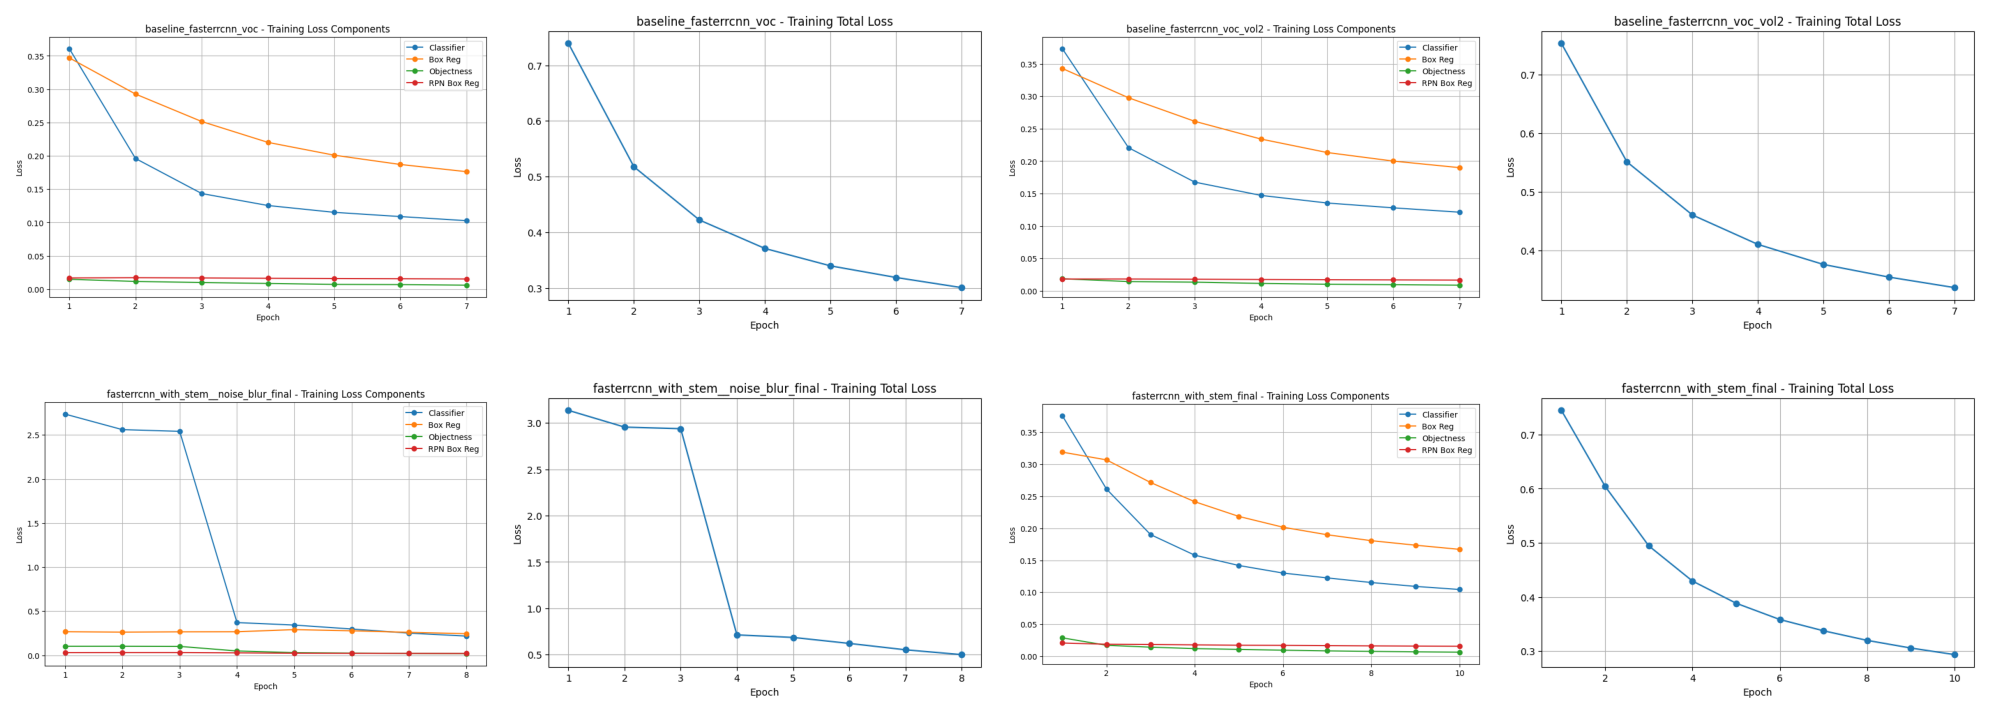

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

images = [
    "baseline_noise.png",
    "baseline_noise_tr_loss.png",
    "baseline_voc.png",
    "baseline_voc_tr_loss.png",
    "pretrained_stem_noise.png",
    "pretrained_stem_noise_tr_loss.png",
    "pretrained_stem_voc.png",
    "pretrained_stem_voc_tr_loss.png"
]

n_images = len(images)

cols = 4
rows = math.ceil(n_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < n_images:
        img = mpimg.imread(images[i])
        ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

data = {
    "Experiment": [

        "STEM VOC (thr=0.5)",
        "STEM VOC (thr=0.3)",
        "STEM VOC (thr=0.05)",


        "STEM Noise (thr=0.5)",
        "STEM Noise (thr=0.3)",
        "STEM Noise (thr=0.05)",


        "Baseline VOC (thr=0.5)",
        "Baseline VOC (thr=0.3)",
        "Baseline VOC (thr=0.05)",


        "Baseline Noise (thr=0.5)",
        "Baseline Noise (thr=0.3)",
        "Baseline Noise (thr=0.05)",
    ],

    "Precision": [
        0.5411, 0.3932, 0.1357,
        0.4693, 0.2955, 0.0562,
        0.6032, 0.4617, 0.1713,
        0.5501, 0.3947, 0.1265
    ],

    "Recall": [
        0.7904, 0.8373, 0.9101,
        0.4606, 0.5795, 0.8143,
        0.8229, 0.8655, 0.9324,
        0.8226, 0.8724, 0.9416
    ],

    "F1 Score": [
        0.6424, 0.5351, 0.2362,
        0.4649, 0.3914, 0.1052,
        0.6962, 0.6022, 0.2894,
        0.6593, 0.5435, 0.2230
    ],

    "mAP@50": [
        0.6621, 0.6892, 0.7108,
        0.2098, 0.2853, 0.3541,
        0.7154, 0.7433, 0.7664,
        0.6990, 0.7303, 0.7518
    ],

    "Mean IoU": [
        0.7900, 0.7856, 0.7774,
        0.7518, 0.7422, 0.7259,
        0.7958, 0.7918, 0.7843,
        0.7943, 0.7902, 0.7826
    ]
}

df = pd.DataFrame(data)
df

,Experiment,Precision,Recall,F1 Score,mAP@50,Mean IoU
0,STEM VOC (thr=0.5),0.5411,0.7904,0.6424,0.6621,0.7900
1,STEM VOC (thr=0.3),0.3932,0.8373,0.5351,0.6892,0.7856
2,STEM VOC (thr=0.05),0.1357,0.9101,0.2362,0.7108,0.7774
3,STEM Noise (thr=0.5),0.4693,0.4606,0.4649,0.2098,0.7518
4,STEM Noise (thr=0.3),0.2955,0.5795,0.3914,0.2853,0.7422
5,STEM Noise (thr=0.05),0.0562,0.8143,0.1052,0.3541,0.7259
6,Baseline VOC (thr=0.5),0.6032,0.8229,0.6962,0.7154,0.7958
7,Baseline VOC (thr=0.3),0.4617,0.8655,0.6022,0.7433,0.7918
8,Baseline VOC (thr=0.05),0.1713,0.9324,0.2894,0.7664,0.7843
9,Baseline Noise (thr=0.5),0.5501,0.8226,0.6593,0.6990,0.7943


Από τα training plots παρατηρείται ότι όλα τα losses πέφτουν και φαίνεται να υπάρχει σύγκλιση. Μεγαλύτερη πτώση έχει το classification loss, ενώ τα localization-related losses (box, RPN) βελτιώνονται πιο σταδιακά.


Στα evaluation metrics παρατηρείται ότι σε όλες τις περιπτώσεις η baseline εκδοχή επιτυγχάνει καλύτερες αποδόσεις, κάτι το οποίο μπορεί να εξηγηθεί από το γεγονός ότι το pretrained μοντέλο έχει μάθει να εξάγει χαρακτηριστικά από συγκεκριμένη μορφή εισόδου. Οπότε, η εισαγωγή του stem τροποποιεί την αναπαράσταση της εικόνας, με αποτέλεσμα τα learned convolutional filters να μην ενεργοποιούνται με τον ίδιο τρόπο,ρίχνοντας τελικά λίγο την απόδοση.
Άρα η αλλαγή της αρχικής αναπαράστασης επηρεάζει αρνητικά τη δυνατότητα του μοντέλου να αξιοποιήσει τα ήδη εκπαιδευμένα χαρακτηριστικά του, παρά τη βοηθάει τονίζοντας χαρακτηριστικά.

Επίσης σε όλες τις περιπτώσεις η προσθήκη noise και blur επέφερε πτώση στις αποδόσεις. Συγκεκριμένα είχε μικρή μείωση στα precision, recall και μεγαλύτερη μείωση στο mAP, το οποίο σημαίνει ότι ο θόρυβος και το blur  επηρρεάζει περισσότερο το localization task παρά το  classification, καθώς μικρές αποκλίσεις στα bounding boxes οδηγούν σε σημαντική πτώση του IoU. Ιδιαίτερα στην περίπτωση stem ο θόρυβος έριξε σημαντικά την mAP, κάτι που μπορεί να δηλώνει πως η προσθήκη stem έκανε πιο ασταθές το μοντέλο και όντως δεν βελτιώνει την επίδοση.

Τέλος όσο μειώνεται το score threshold, τόσο αυξάνεται το recall ( περισσότερα true positives) και πέφει το precision(αυξάνονται τα false positives), αφού οι περισσότερες προβλέψεις γίνονται δεκτές ως true αλλά λιγότερες από αυτές είναι πραγματικά true.

## Pretrained Model with custom backbone - Results

### lr 0.0005

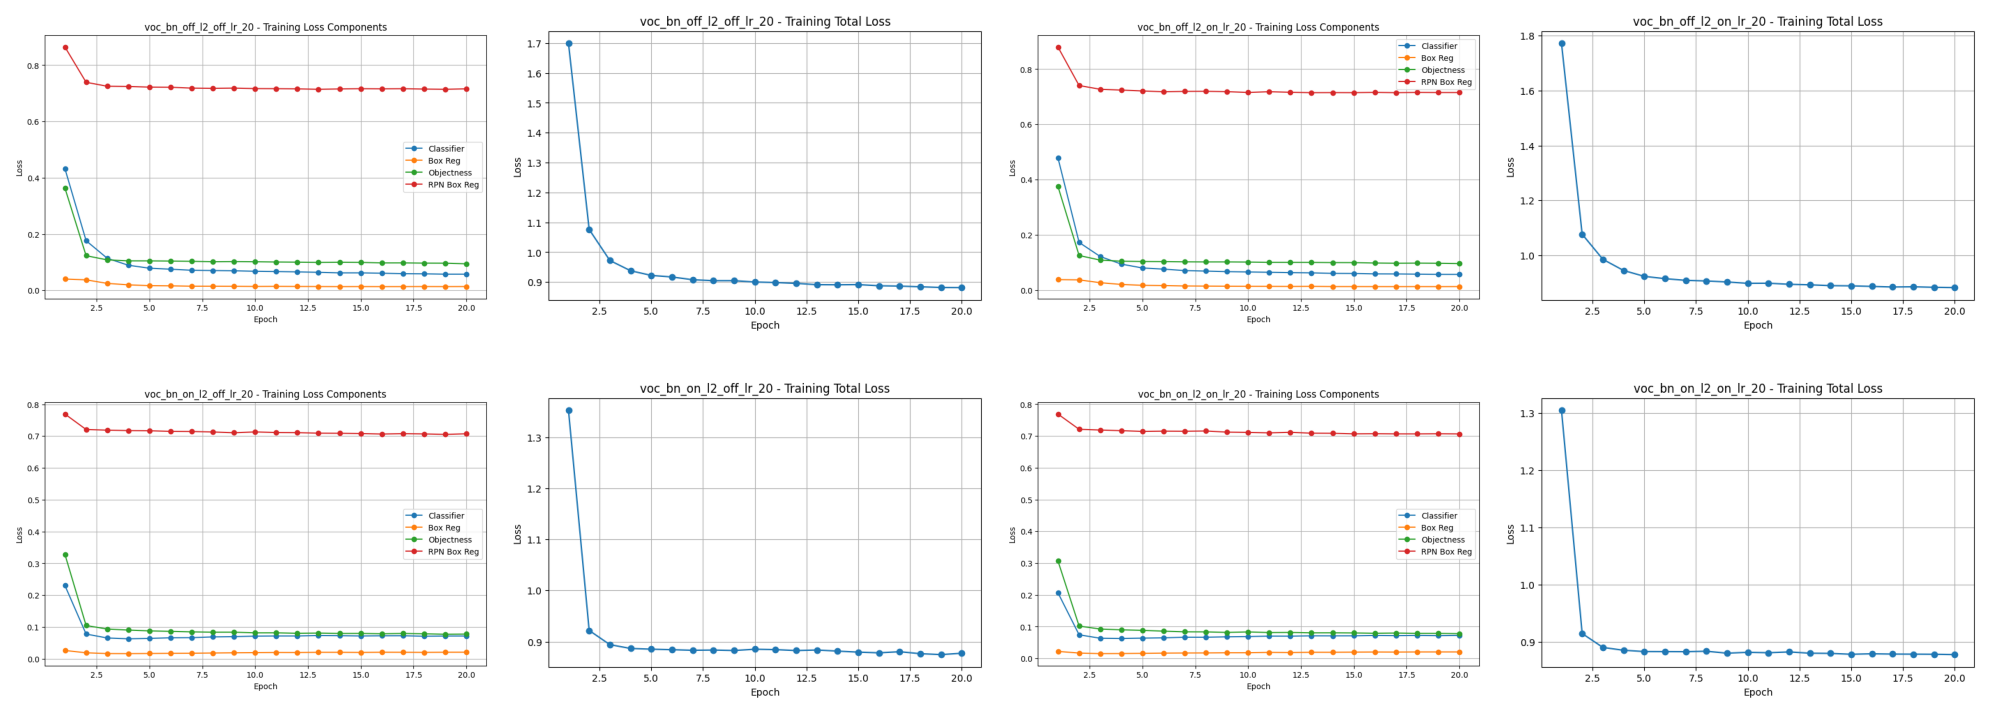

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

images = [
    "/content/voc_off_off_.png",
    "/content/voc_off_off__loss.png",
    "/content/voc_off_on.png",
    "/content/voc_off_on_loss.png",
    "/content/voc_on_off.png",
    "/content/voc_on_off_loss.png",
    "/content/voc_on_on.png",
    "/content/voc_on_on_loss.png"
]

n_images = len(images)

cols = 4
rows = math.ceil(n_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < n_images:
        img = mpimg.imread(images[i])
        ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

data = {
    "Experiment": [
        "BN OFF + L2 OFF",
        "BN ON + L2 OFF",
        "BN OFF + L2 ON",
        "BN ON + L2 ON"
    ],

    "mAP": [
        0.0024,
        0.0225,
        0.0035,
        0.0102
    ],

    "F1 Score": [
        0.1458,
        0.2595,
        0.1329,
        0.1947
    ],

    "Precision": [
        0.1209,
        0.1283,
        0.1080,
        0.1530
    ],

    "Recall": [
        0.1836,
        0.2712,
        0.1725,
        0.2685
    ],

    "Mean IoU": [
        0.6108,
        0.6200,
        0.6083,
        0.6145
    ]
}

df = pd.DataFrame(data)
df

,Experiment,mAP,F1 Score,Precision,Recall,Mean IoU
0,BN OFF + L2 OFF,0.0024,0.1458,0.1209,0.1836,0.6108
1,BN ON + L2 OFF,0.0225,0.2595,0.1283,0.2712,0.6200
2,BN OFF + L2 ON,0.0035,0.1329,0.1080,0.1725,0.6083
3,BN ON + L2 ON,0.0102,0.1947,0.1530,0.2685,0.6145


Τα anchors σε αυτά τα πειράματα (και στο παρακάτω με προσθήκη noise blur) ήταν sizes=((32,), (64,), (128,)) τα οποία είναι σχετικά περιορισμένα. Για Pascal VOC υπάρχουν αντικείμενα με πολύ διαφορετικά μεγέθη. Άρα το RPN μπορεί να μην παράγει καλά proposals, κάτι που συμφωνεί με το ότι στα plots το RPN box regression loss είναι σχετικά σταθερό.


Επομένως, στο πρώτο σύνολο πειραμάτων με custom backbone και περιορισμένο anchor setup, τα training losses μειώνονται γρήγορα και σταθεροποιούνται, γεγονός που δεν δείχνει κάποιο πρόβλημα στην εκπαίδευση, ωστόσο, τα detection metrics από το evaluation είναι πολύ χαμηλά, με σχεδόν μηδενικό mAP. Αυτό υποδηλώνει ότι η μείωση του loss δεν μεταφράζεται απαραίτητα σε καλή ανίχνευση αντικειμένων. Επίσης, φαίνεται πως η απλή custom backbone αρχιτεκτονική πιθανόν δεν εξάγει αρκετά ισχυρά χαρακτηριστικά σε σχέση με ένα pretrained backbone, ενώ το περιορισμένο anchor setup δυσκολεύει την παραγωγή κατάλληλων region proposals. Επίσης, από ό,τι φαίνεται, η χρήση Batch Normalization βοηθά ελαφρώς, αλλά καμία από τις παραλλαγές BN/L2 δεν οδηγεί σε ικανοποιητική απόδοση.

Παρακάτω είναι τα αποτελέσματα για run lr 0.001, τα οποία είναι χαμηλότερα από ό,τι για 0.0005. Στα υπόλοιπα πειράματα χρησιμοποιήθηκε lr 0.0005

In [ ]:
import pandas as pd

data = {
    "Experiment": [
        "BN ON + L2 ON",
        "BN ON + L2 OFF",
        "BN OFF + L2 ON",
        "BN OFF + L2 OFF"
    ],


    "mAP": [
        0.0034,
        0.0075,
        0.0015,
        0.0018
    ],

    "F1 Score": [
        0.1683,
        0.0873,
        0.0443,
        0.1508
    ],

    "Precision": [
        0.1510,
        0.0761,
        0.0360,
        0.1403
    ],

    "Recall": [
        0.1895,
        0.1004,
        0.0575,
        0.1612
    ],

    "Mean IoU": [
        0.6108,
        0.6200,
        0.6083,
        0.6145
    ]


}

df = pd.DataFrame(data)
df

,Experiment,mAP,F1 Score,Precision,Recall,Mean IoU
0,BN ON + L2 ON,0.0034,0.1683,0.1510,0.1895,0.6108
1,BN ON + L2 OFF,0.0075,0.0873,0.0761,0.1004,0.6200
2,BN OFF + L2 ON,0.0015,0.0443,0.0360,0.0575,0.6083
3,BN OFF + L2 OFF,0.0018,0.1508,0.1403,0.1612,0.6145


Με προσθήκη θορύβου λρ 0.0005

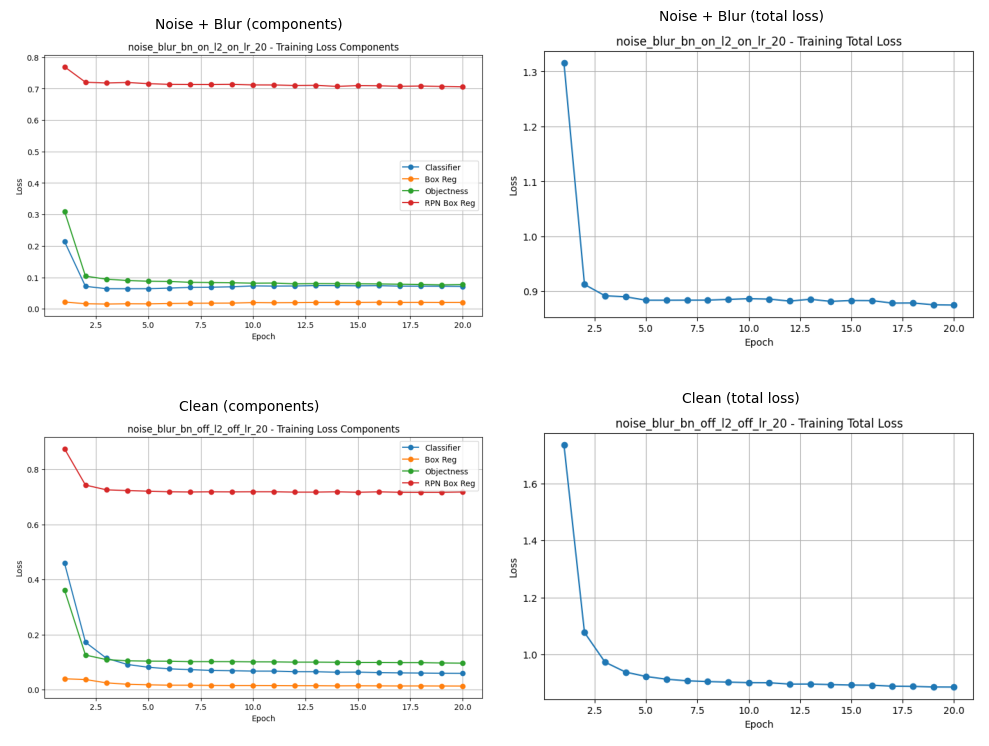

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

images = [
    "noise_blur_on_on.png",
    "noise_blur_on_on_loss.png",
    "noise_off_off.png",
    "noise_off_off_loss.png"
]

titles = [
    "Noise + Blur (components)",
    "Noise + Blur (total loss)",
    "Clean (components)",
    "Clean (total loss)"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(images[i])
    ax.imshow(img)
    ax.set_title(titles[i], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

data = {
    "Experiment": [
        "Noise + Blur (BN OFF + L2 OFF)",
        "Noise + Blur (BN ON + L2 ON)"
    ],

    "Precision": [
        0.0840,
        0.1449
    ],

    "Recall": [
        0.1305,
        0.1896
    ],

    "F1 Score": [
        0.1024,
        0.1642
    ],

    "mAP": [
        0.0016,
        0.0030
    ],

    "Mean IoU": [
        0.6003,
        0.6015
    ]
}

df = pd.DataFrame(data)
df

,Experiment,Precision,Recall,F1 Score,mAP,Mean IoU
0,Noise + Blur (BN OFF + L2 OFF),0.0840,0.1305,0.1024,0.0016,0.6003
1,Noise + Blur (BN ON + L2 ON),0.1449,0.1896,0.1642,0.0030,0.6015


Στα πειράματα με NoiseBlur, η προσθήκη Batch Normalization και L2 regularization βελτιώνει ελαφρώς την απόδοση σε σχέση με την εκδοχή χωρίς BN και L2. Ωστόσο, οι συνολικές τιμές των metrics παραμένουν πολύ χαμηλές, με σχεδόν μηδενικό mAP. Παρότι τα training losses μειώνονται και σταθεροποιούνται, το υψηλό και σχεδόν σταθερό RPN box regression loss δείχνει ότι το custom backbone δυσκολεύεται να παράγει χαρακτηριστικά κατάλληλα για ακριβή region proposals. Συνεπώς, η χρήση BN και L2 προσφέρει μικρή σταθεροποίηση, αλλά δεν φαίνεται να αρκεί για να αντισταθμίσει τους περιορισμούς του απλού custom backbone.

### anchors lr 0.005

Για τη βελτίωση της απόδοσης του μοντέλου τροποποιήθηκε ο anchor generator με περισσότερα anchor sizes, με σκοπό να προσαρμόζονται τα anchors καλύτερα στα  αντικείμενα.
Επίσης, επειδή τα αρχικά αποτελέσματα εμφάνιζαν πολύ μεγάλο αριθμό false positives και ιδιαίτερα χαμηλό precision, προστέθηκαν παράμετροι όπως τα thresholds του Non Maximum Suppression (NMS), ο αριθμός των proposals που διατηρούνται μετά το RPN, καθώς και το box_detections_per_img, ώστε να περιοριστούν κάποιες λανθασμένες προβλέψεις.

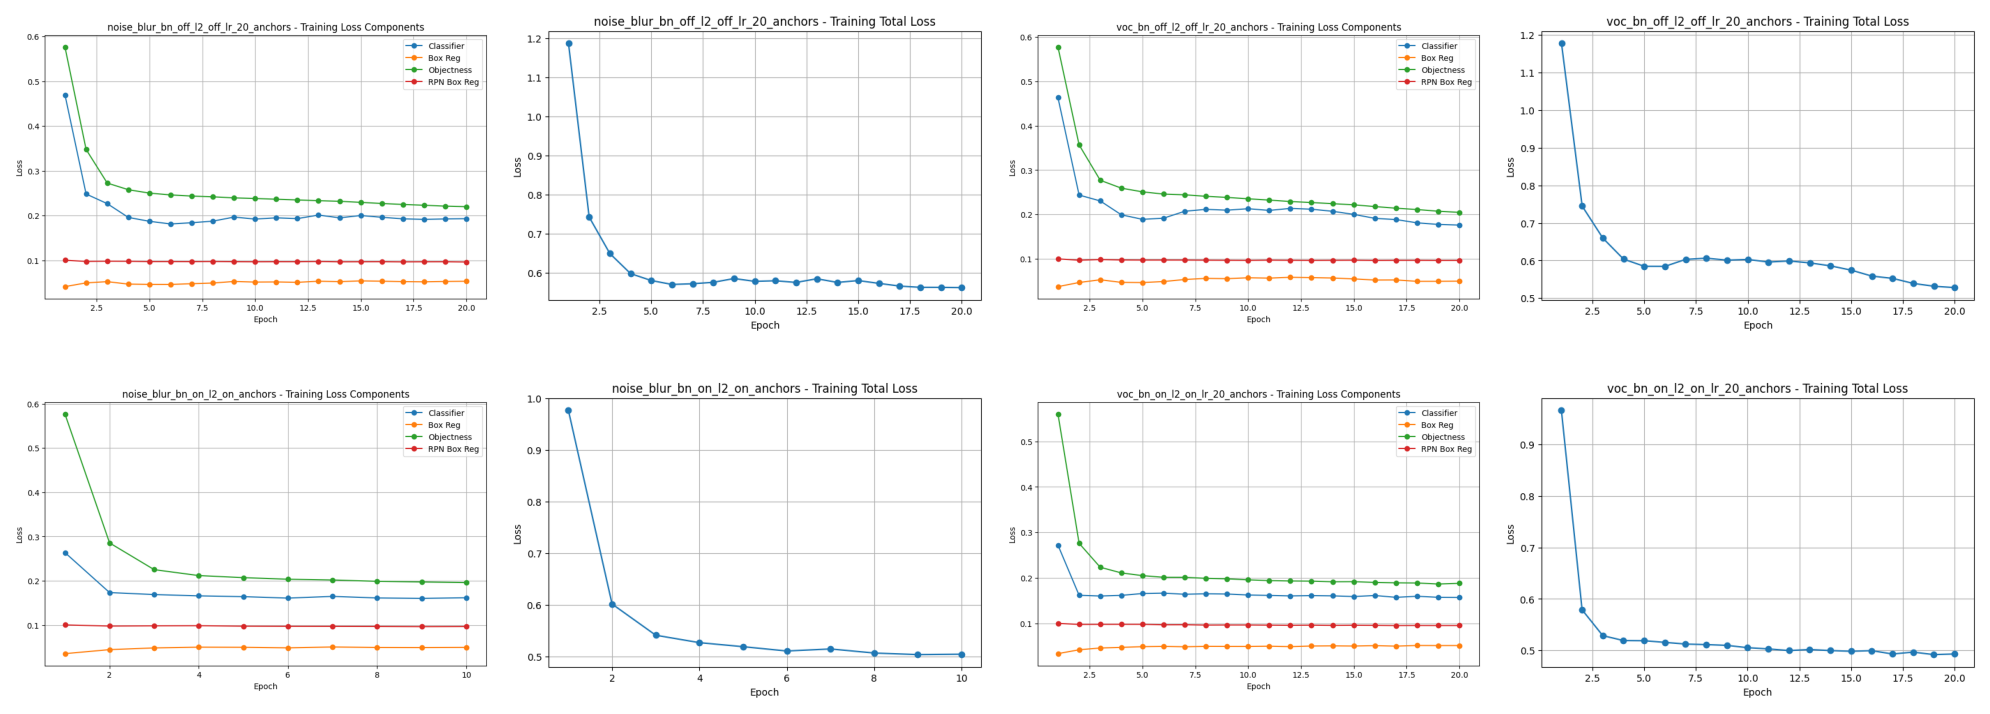

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

base_path = "/content/"

images = [
    base_path + "noise_off_off.png",
    base_path + "noise_off_off_loss.png",

    base_path + "voc_off_loff.png",
    base_path + "voc_off_loff_loss.png",

    base_path + "noise_on_on.png",
    base_path + "noise_on_on_loss.png",

    base_path + "voc_on_on.png",
    base_path + "voc_on_on_loss.png"
]
cols = 4
rows = math.ceil(len(images) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(images[i])
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

data = {
    "Experiment": [
        "Noise (BN OFF + L2 OFF + Anchors)",
        "Noise (BN ON + L2 ON + Anchors)",
        "VOC (BN OFF + L2 OFF + Anchors)",
        "VOC (BN ON + L2 ON + Anchors)"
    ],

    "Precision": [
        0.1227,
        0.1356,
        0.1509,
        0.1677
    ],

    "Recall": [
        0.1491,
        0.1569,
        0.1356,
        0.1776
    ],

    "F1 Score": [
        0.1347,
        0.1455,
        0.1428,
        0.1725
    ],

    "mAP": [
        0.0015,
        0.0015,
        0.0015,
        0.0039
    ],

    "Mean IoU": [
        0.6141,
        0.6142,
        0.6164,
        0.6164
    ]
}

df = pd.DataFrame(data)
df

,Experiment,Precision,Recall,F1 Score,mAP,Mean IoU
0,Noise (BN OFF + L2 OFF + Anchors),0.1227,0.1491,0.1347,0.0015,0.6141
1,Noise (BN ON + L2 ON + Anchors),0.1356,0.1569,0.1455,0.0015,0.6142
2,VOC (BN OFF + L2 OFF + Anchors),0.1509,0.1356,0.1428,0.0015,0.6164
3,VOC (BN ON + L2 ON + Anchors),0.1677,0.1776,0.1725,0.0039,0.6164


Η χρήση περισσότερων anchor sizes οδήγησε σε μικρή βελτίωση των αποτελεσμάτων, ιδιαίτερα στην εκδοχή VOC με BN και L2, ενω στα plots το RPN box regression loss πέφτει αισθητά. Ωστόσο, τα συνολικά metrics παραμένουν χαμηλά και το mAP σχεδόν μηδενικό. Αυτό δείχνει ότι η βελτίωση των anchors βοηθά την παραγωγή proposals, αλλά δεν επαρκεί όταν το backbone δεν διαθέτει αρκετή αναπαραστατική ικανότητα.


Οπότε συνολικά, το custom backbone παρουσίασε χαμηλές επιδόσεις, πιθανότατα επειδή είναι απλοποιημένη αρχιτεκτονική σε σχέση με τα κλασικά pretrained backbones που χρησιμοποιούνται στο Faster R-CNNs και τα feature maps που παράγει δεν ανταγωνίζονται ένα pretrained ResNet.

Οι καμπύλες δείχνουν ότι το loss μειώνεται γρήγορα στις πρώτες εποχές και μετά κάνει σχεδόν plateau, οπότε πιθανώς με τη συγκεκριμένη αρχιτεκτονική δεν θα εμφανίζει σημαντική περαιτέρω βελτίωση με περισσότερη εκπαίδευση, εφόσον τα αποτελέσματα είναι χαμηλά και οι βελτιώσεις τους μικρές.

Σημαντικό είναι ότι χρειάστηκε threshold 0.05 για να δώσει μη μηδενικά metrics, το οποίο δείχνει ότι το μοντέλο παράγει προβλέψεις με πολύ χαμηλό confidence και άρα δεν είναι σίγουρο για τα detections. Στα thresholds 0.5 ή 0.3 έβγαζε πολύ χαμηλότερα (σχεδόν όλα μηδενικά) metrics, επειδή σχεδόν καμία πρόβλεψη δεν περνά το φίλτρο εμπιστοσύνης.


Το Mean IoU (~0.6) δείχνει ότι όταν υπάρχουν σωστές προβλέψεις, τα bounding boxes έχουν ικανοποιητική χωρική επικάλυψη. Ωστόσο, αυτό συμβαίνει για πολύ περιορισμένο αριθμό ανιχνεύσεων. Επομένως, το βασικό πρόβλημα εντοπίζεται στην ανίχνευση και στο confidence των προβλέψεων, και όχι τόσο στην ποιότητα των bounding boxes.

Το BN + L2 δίνει μικρή βελτίωση, ειδικά στο VOC, όμως η βελτίωση είναι πολύ μικρή και δεν αλλάζει το βασικό συμπέρασμα.

## YOLO - Results

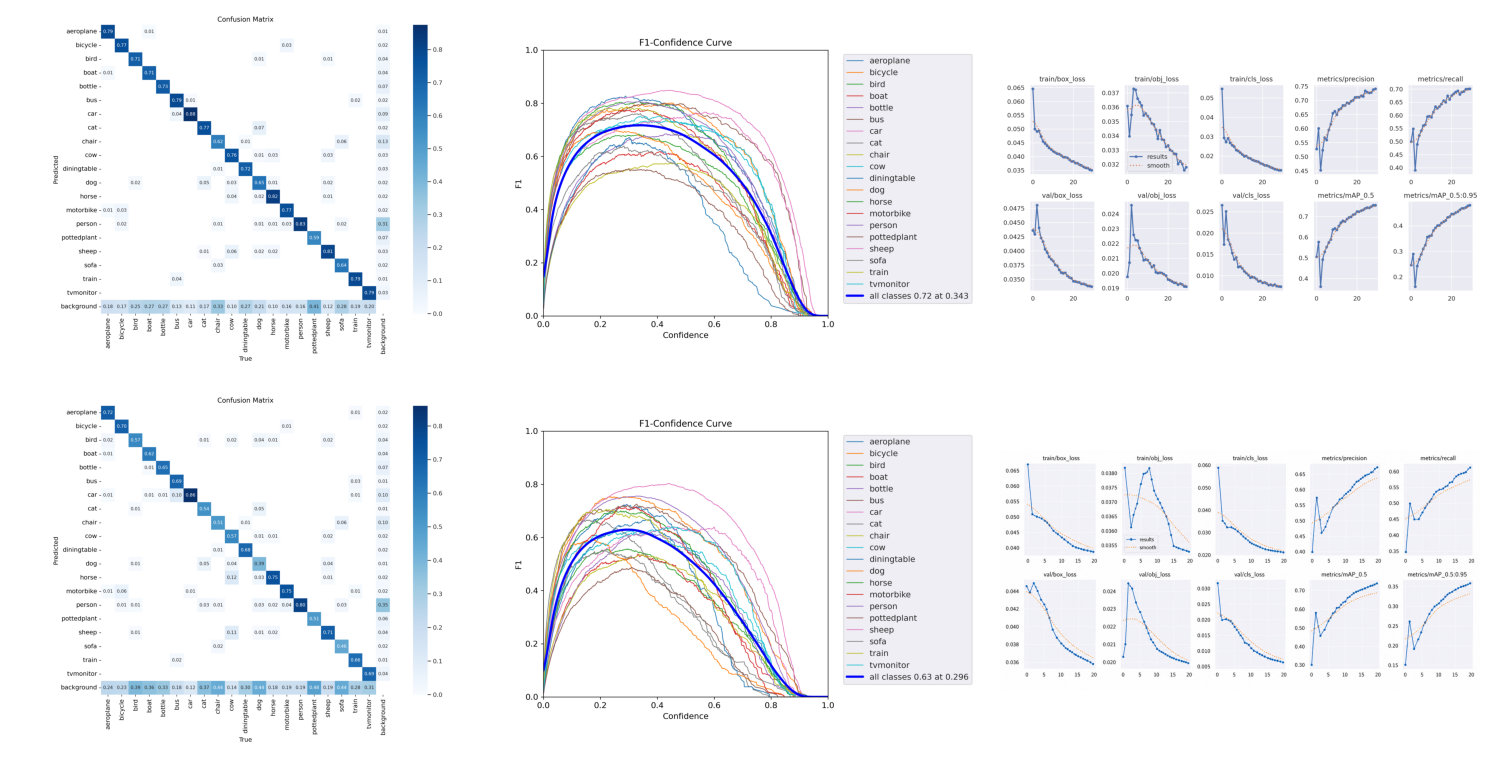

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

images = [
    "voc cf.png",
    "voc f.png",
    "vocresults.png",
    "noise cf.png",
    "noise f.png",
    "noise results.png"
]

n_images = len(images)

cols = 3
rows = math.ceil(n_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < n_images:
        img = mpimg.imread(images[i])
        ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

data = {
    "Metric": ["Precision", "Recall", "mAP@0.50", "mAP@0.50:0.95"],
    "YOLOv5n (clean VOC)": [0.707, 0.693, 0.733, 0.459],
    "YOLOv5n (noise+blur)": [0.596, 0.561, 0.578, 0.327]
}

df = pd.DataFrame(data)
df

,Metric,YOLOv5n (clean VOC),YOLOv5n (noise+blur)
0,Precision,0.707,0.596
1,Recall,0.693,0.561
2,mAP@0.50,0.733,0.578
3,mAP@0.50:0.95,0.459,0.327


Γενικά, το μοντέλο παρουσιάζει καλή συμπεριφορά και στα δύο σύνολα δεδομένων (VOC clean και VOC με θόρυβο), καθώς παρατηρείται σύγκλιση κατά την εκπαίδευση και σταθερή μείωση των losses.

Ωστόσο, το μοντέλο αποδίδει καλύτερα στο καθαρό σύνολο δεδομένων (VOC clean), καθώς όλα τα metrics (precision, recall, mAP) εμφανίζουν υψηλότερες τιμές σε σύγκριση με την εκδοχή με θόρυβο (NoiseBlur).

Η διαφορά μεταξύ των δύο συνόλων είναι μικρότερη στα metrics precision και recall, ενώ είναι  μεγαλύτερη στα mAP metrics, ιδιαίτερα στο mAP 0.5:0.95, το οποίο είναι ο μέσος όρος του Average Precision (AP) για πολλαπλά κατώφλια IoU, από 0.50 έως 0.95 με βήμα 0.05.  Αυτό επίσης υποδηλώνει ότι η παρουσία θορύβου επηρεάζει περισσότερο την ακρίβεια εντοπισμού (localization) των bounding boxes σε σχέση με την ικανότητα ταξινόμησης (classification).

Η συμπεριφορά αυτή μπορεί να εξηγηθεί πιθανώς από το ότι ο θόρυβος και το blur αλλοιώνουν τα όρια των αντικειμένων, καθιστώντας πιο δύσκολη την ακριβή εκτίμηση των bounding boxes. Αντίθετα, για την ταξινόμηση, τα συνελικτικά επίπεδα (convolutional layers) βασίζονται σε πιο αφηρημένα χαρακτηριστικά (όπως σχήμα και υφή), τα οποία είναι πιο ανθεκτικά σε τέτοιου είδους αλλοιώσεις. Παρόμοια συμπεριφορά  υπ΄ήρχε για θορυβώδη δεδομένα και στις προηγούμενες περιπτώσεις.

Το γεγονός ότι αυξάνοντας το κατώφλι IoU μειώνεται το mAp ήταν αναμενόμενο καθώς αυξάνοντας το κατώφλι IoU, το κριτήριο για να θεωρηθεί μια πρόβλεψη σωστή γίνεται αυστηρότερο, απαιτώντας μεγαλύτερη επικάλυψη μεταξύ προβλεπόμενου και πραγματικού bounding box, οπότε και οι τιμές AP μειώνονται.

Επιπλέον, οι confusion matrices και στις δύο περιπτώσεις παρουσιάζουν έντονη διαγώνιο, γεγονός που υποδηλώνει σωστή αντιστοίχιση προβλέψεων με ground truth αντικείμενα. Παρ’ όλα αυτά, στην περίπτωση του VOC clean η διαγώνιος είναι ελαφρώς πιο έντονη, υποδεικνύοντας ελαφρώς καλύτερη απόδοση.

Τέλος, οι τιμές των metrics evaluation είναι πολύ κοντινές με αυτές του baseline pre-trained Fatser RCNN, με πιο έντονες διαφορές στην περίπτωση noise, blur όπου το pre-trained Faster RCNN έχει καλύτερη απόδοση. Σε όλες τις περιπτώσεις επίσης το pre-trained Faster RCNN έχει υψηλότερο recall.

## Σύνοψη

Τα μοντέλα με custom backbone παρουσίασαν σημαντικά χαμηλότερες επιδόσεις, γεγονός που υποδηλώνει ότι η εκμάθηση ισχυρών και γενικεύσιμων χαρακτηριστικών από την αρχή είναι ιδιαίτερα δύσκολη στο object detection.

Οι τεχνικές βελτίωσης όπως Batch Normalization, L2 regularization και ρύθμιση των anchors οδήγησαν σε μικρές βελτιώσεις για όλες τις περιπτώσεις. Όμως, παρότι συνέβαλαν στην αύξηση αποδόσεων, δεν ήταν αρκετές για να αντισταθμίσουν τα προβλήματα που προκύπτουν από αδύναμα feature representations.
<br></br>
Η προσθήκη stem δεν οδήγησε σε βελτίωση της απόδοσης, αλλά αντίθετα, προκάλεσε υποβάθμιση, πιθανώς λόγω ασυμβατότητας με τα pretrained features.
<br></br>
Και στα δύο μοντέλα (YOLO και Faster R-CNN), η παρουσία θορύβου και blur οδήγησε σε μείωση της απόδοσης. Η επίδραση ήταν εντονότερη στα mAP metrics, γεγονός που υποδηλώνει ότι το localization επηρεάζεται περισσότερο από το classification.



